# 🧠 Brain Tumor Segmentation — Attention U-Net vs HRNet-OCR (Hybrid Pipeline)

**Phase 1 Workflow (Final)**

1. **Data Preprocessing** (`DatasetPreprocessor`) — load BraTS2020 volumes, filter
   non-tumor slices, resize to 160×160, per-channel Z-score normalization, 7
   data augmentations.
2. **Feature Extraction** (`FeatureExtractor`) — Attention U-Net (fine + coarse
   features) and HRNet-OCR (multi-scale object-contextual features).
3. **Train & Evaluate Individual Models** (`ModelTrainer`) — trains Attention
   U-Net and HRNet-OCR **separately**, each with the Hybrid Loss
   (Dice + Focal + Boundary), reports Dice / IoU / Accuracy, and shows a
   **side-by-side comparison dashboard** of both models.

Segmentation classes (BraTS convention):
* `0` – Not tumor
* `1` – Necrotic / non-enhancing tumor core (NCR/NET)
* `2` – Peritumoral edema (ED)
* `3` – Enhancing tumor (ET)


## ⚙️ 0. Environment Setup (Colab optional)

Run the two cells below **only** if you are on Google Colab and need to mount
Drive / unzip the dataset. Skip them on a local machine that already has the
BraTS2020 data on disk.

In [1]:
# --- OPTIONAL: Google Colab only -----------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running in Colab — skipping drive mount.")


Mounted at /content/drive


In [2]:
# --- OPTIONAL: install/upgrade dependencies -------------------------------
import sys, subprocess

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

# Uncomment if a package is missing in your environment:
# _pip_install("nibabel", "nilearn", "h5py", "scikit-image", "opencv-python-headless")
print("Dependency check skipped (assumes packages are already installed).")


Dependency check skipped (assumes packages are already installed).


## 📥 1. Imports

In [3]:
import os
import re
import cv2
import glob
import json
import random
import datetime
import multiprocessing as mp

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import h5py

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization,
    Activation, Multiply, Add, Conv2DTranspose, Softmax, Reshape, Lambda, Layer
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, CSVLogger, TensorBoard
)
from tensorflow.keras.utils import Sequence, register_keras_serializable
from tensorflow.keras import backend as K

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:     ", tf.keras.__version__ if hasattr(tf.keras, '__version__') else "n/a")


TensorFlow: 2.20.0
Keras:      3.13.2


## 🔧 2. Configuration

In [4]:
# ----- 🔧 EDIT THESE FOR YOUR MACHINE -----
TRAIN_DATASET_PATH = "/content/drive/MyDrive/Brain/BraTS2020_training_data/content/data"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
LOG_DIR = os.path.join(OUTPUT_DIR, "logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(LOG_DIR, exist_ok=True)
# -------------------------------------------

IMG_SIZE          = 160          # slices are resized to IMG_SIZE x IMG_SIZE
IN_CHANNELS       = 4            # FLAIR, T1, T1CE, T2
NUM_CLASSES       = 2            # binary — 0 = background, 1 = whole tumor
VOLUME_SLICES     = 100          # slices sampled per patient volume
VOLUME_START_AT   = 22           # first slice index to sample from
MIN_TUMOR_PIXELS  = 80           # slices with fewer tumor pixels are dropped (cleaner masks)
N_PATIENTS        = 60           # 🔁 CHANGED: 50 -> 60 patient volumes

BATCH_SIZE   = 16
EPOCHS       = 70                # 🔁 CHANGED: 45 -> 70, with EarlyStopping so it stops itself
LR           = 1e-4
BASE_FILTERS = 48                # 🔁 CHANGED: 32 -> 48 — more capacity to push Dice past 0.90

# Binary WHOLE-TUMOR segmentation (Background vs Tumor) — the three BraTS
# sub-regions (NCR/NET, ED, ET) are merged into one "Tumor" class inside
# DatasetPreprocessor.load_slice().
SEGMENT_CLASSES = {
    0: 'NOT tumor',
    1: 'TUMOR',
}

# Modality channel order inside each .h5 'image' array (BraTS2020 h5 convention)
MODALITY_NAMES = ['FLAIR', 'T1', 'T1CE', 'T2']

CUSTOM_OBJECTS = {}   # filled in as custom losses / layers are defined below


### 🔎 2.1 Auto-detect the real dataset folder (fixes "Found 0 patient volumes")

The BraTS2020 zip usually extracts with an extra nested folder (e.g.
`BraTS2020_training_data/content/data/` or similar), so a hardcoded path
often doesn't match. This cell **searches your Drive/Brain folder
recursively** for the actual `.h5` slice files and updates
`TRAIN_DATASET_PATH` automatically if it finds them somewhere else.

In [5]:
import glob as _glob

def auto_detect_dataset_path(search_roots, filename_pattern="volume_*_slice_*.h5"):
    """Searches each root recursively for BraTS .h5 slices and returns the
    folder that actually contains them (or None if nothing is found)."""
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        hits = _glob.glob(os.path.join(root, "**", filename_pattern), recursive=True)
        if hits:
            return os.path.dirname(hits[0]), len(hits)
    return None, 0

# Check the configured path first; if it's wrong, search a few likely roots.
_search_roots = [
    TRAIN_DATASET_PATH,
    "/content/drive/MyDrive/Brain",
    "/content/drive/MyDrive",
]

_found_path, _n_hits = auto_detect_dataset_path(_search_roots)

if _found_path:
    if _found_path != TRAIN_DATASET_PATH:
        print(f"⚠️  Configured TRAIN_DATASET_PATH did not contain any .h5 files.")
        print(f"✅  Auto-detected the real data folder instead:\n    {_found_path}")
        print(f"    ({_n_hits} matching .h5 files found)")
        TRAIN_DATASET_PATH = _found_path
    else:
        print(f"✅  TRAIN_DATASET_PATH is correct — {_n_hits} .h5 files found.")
else:
    print("❌  No BraTS .h5 files found under any of:")
    for r in _search_roots:
        print("   -", r)
    print("    Double-check the zip actually extracted, and that you ran the "
          "'unzip' cell above. You can also set TRAIN_DATASET_PATH manually "
          "to the exact folder that contains files named like "
          "'volume_1_slice_50.h5'.")


✅  TRAIN_DATASET_PATH is correct — 45448 .h5 files found.


## 🧹 3. Phase 1 — Data Preprocessing (`DatasetPreprocessor`)

Responsibilities:
* Loads BraTS2020 MRI volumes (T1, T1CE, T2, FLAIR) from the per-slice `.h5` files.
* **Filters out non-tumor slices** (fewer than `MIN_TUMOR_PIXELS` tumor pixels are dropped).
* **Resizes** every slice to `IMG_SIZE × IMG_SIZE`.
* Applies **per-channel Z-score normalization** (computed over the brain / non-zero region).
* Performs **7 data augmentations**: horizontal flip, vertical flip, rotation, random
  scale/zoom, random translation, gamma/brightness jitter, and elastic deformation.

Output: `processed_data` (stacked 4-channel image) and the corresponding one-hot **ground-truth mask**.

In [6]:
class DatasetPreprocessor:
    """Phase 1 — Data Preprocessing.

    Loads BraTS2020 .h5 slices, filters tumor-only slices, resizes to
    `img_size`, applies per-channel Z-score normalization, and offers 7
    data augmentations for training-time use.
    """

    AUG_LIST = ['h_flip', 'v_flip', 'rotate', 'scale', 'translate', 'gamma', 'elastic']

    def __init__(self, data_path=TRAIN_DATASET_PATH, img_size=IMG_SIZE,
                 in_channels=IN_CHANNELS, num_classes=NUM_CLASSES,
                 volume_slices=VOLUME_SLICES, volume_start_at=VOLUME_START_AT,
                 min_tumor_pixels=MIN_TUMOR_PIXELS, seed=SEED):
        self.data_path = data_path
        self.img_size = img_size
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.volume_slices = volume_slices
        self.volume_start_at = volume_start_at
        self.min_tumor_pixels = min_tumor_pixels
        self.rng = np.random.RandomState(seed)

    # ---------------------------------------------------------------
    # Discover available patient volumes
    # ---------------------------------------------------------------
    def list_volume_ids(self):
        if not os.path.isdir(self.data_path):
            print(f"[DatasetPreprocessor] Data path not found: {self.data_path}")
            return []
        # Look directly in data_path first ...
        files = glob.glob(os.path.join(self.data_path, "volume_*_slice_*.h5"))
        # ... and fall back to a recursive search in case the real .h5 files
        # ended up one or more folders deeper (very common after unzipping,
        # e.g. an extra `BraTS2020_training_data/` or `content/data/` layer).
        if not files:
            files = glob.glob(os.path.join(self.data_path, "**", "volume_*_slice_*.h5"),
                               recursive=True)
            if files:
                # Re-point data_path at the folder that actually holds the .h5 files
                self.data_path = os.path.dirname(files[0])
                print(f"[DatasetPreprocessor] Auto-detected real data folder: {self.data_path}")
        ids = sorted({int(re.findall(r"volume_(\d+)_slice_", os.path.basename(fp))[0])
                      for fp in files})
        return ids

    # ---------------------------------------------------------------
    # Per-channel Z-score normalization
    # ---------------------------------------------------------------
    @staticmethod
    def normalize_channel(img2d):
        brain = img2d > 0
        if brain.sum() == 0:
            return np.zeros_like(img2d, dtype=np.float32)
        mean = img2d[brain].mean()
        std = img2d[brain].std() + 1e-8
        z = (img2d - mean) / std
        z = np.clip(z, -5, 5)
        z = (z - z.min()) / (z.max() - z.min() + 1e-8)
        return z.astype(np.float32)

    # ---------------------------------------------------------------
    # Filter tumor-only slices for one volume (multiprocessing worker)
    # ---------------------------------------------------------------
    def scan_volume(self, volume_id):
        valid_slices = []
        for j in range(self.volume_slices):
            slice_idx = j + self.volume_start_at
            h5_file = os.path.join(self.data_path, f"volume_{volume_id}_slice_{slice_idx}.h5")
            if not os.path.exists(h5_file):
                continue
            try:
                with h5py.File(h5_file, 'r') as f:
                    msk = f['mask'][:]
            except Exception:
                continue
            if msk.sum() >= self.min_tumor_pixels:
                valid_slices.append(slice_idx)
        return volume_id, valid_slices

    def build_slice_index(self, volume_ids, n_jobs=None):
        """Returns a flat list of (volume_id, slice_idx) tuples for every
        slice that passed the tumor-pixel filter."""
        n_jobs = n_jobs or max(1, mp.cpu_count() - 1)
        index = []
        try:
            with mp.Pool(n_jobs) as pool:
                for volume_id, valid_slices in tqdm(
                        pool.imap_unordered(self.scan_volume, volume_ids),
                        total=len(volume_ids), desc="Scanning volumes for tumor slices"):
                    index.extend([(volume_id, s) for s in valid_slices])
        except Exception:
            for vid in tqdm(volume_ids, desc="Scanning volumes for tumor slices"):
                _, valid_slices = self.scan_volume(vid)
                index.extend([(vid, s) for s in valid_slices])
        return index

    # ---------------------------------------------------------------
    # Load + resize + normalize a single slice
    # ---------------------------------------------------------------
    def load_slice(self, volume_id, slice_idx):
        h5_file = os.path.join(self.data_path, f"volume_{volume_id}_slice_{slice_idx}.h5")
        with h5py.File(h5_file, 'r') as f:
            img = f['image'][:]     # (H, W, 4) modality order per BraTS2020 h5 convention
            msk = f['mask'][:]      # (H, W, 3) one-hot NCR/ED/ET channels

        X = np.zeros((self.img_size, self.img_size, self.in_channels), dtype=np.float32)
        for c in range(self.in_channels):
            ch = cv2.resize(img[:, :, c].astype(np.float32), (self.img_size, self.img_size))
            X[:, :, c] = self.normalize_channel(ch)

        # 🔁 CHANGED: collapse the 3 BraTS sub-region channels (NCR/NET, ED, ET)
        # into ONE binary "whole tumor" channel — this is the Background-vs-
        # Tumor task shown in the reference dashboard, and it removes most of
        # the class imbalance that made the 4-class Dice so low.
        msk_resized = cv2.resize(msk.astype(np.float32), (self.img_size, self.img_size),
                                  interpolation=cv2.INTER_NEAREST)
        if msk_resized.ndim == 2:
            msk_resized = msk_resized[..., None]
        tumor_binary = np.clip(msk_resized.sum(axis=-1), 0, 1).astype(np.float32)

        Y = np.zeros((self.img_size, self.img_size, self.num_classes), dtype=np.float32)
        Y[:, :, 0] = 1.0 - tumor_binary   # background
        Y[:, :, 1] = tumor_binary          # tumor (whole)

        return X, Y

    # ---------------------------------------------------------------
    # 7 data augmentations
    # ---------------------------------------------------------------
    def _h_flip(self, X, Y):
        return X[:, ::-1, :], Y[:, ::-1, :]

    def _v_flip(self, X, Y):
        return X[::-1, :, :], Y[::-1, :, :]

    def _rotate(self, X, Y, max_angle=15):
        angle = self.rng.uniform(-max_angle, max_angle)
        M = cv2.getRotationMatrix2D((self.img_size / 2, self.img_size / 2), angle, 1.0)
        Xr = cv2.warpAffine(X, M, (self.img_size, self.img_size), flags=cv2.INTER_LINEAR)
        Yr = cv2.warpAffine(Y, M, (self.img_size, self.img_size), flags=cv2.INTER_NEAREST)
        return Xr, Yr

    def _scale(self, X, Y, scale_range=(0.9, 1.1)):
        s = self.rng.uniform(*scale_range)
        M = cv2.getRotationMatrix2D((self.img_size / 2, self.img_size / 2), 0, s)
        Xs = cv2.warpAffine(X, M, (self.img_size, self.img_size), flags=cv2.INTER_LINEAR)
        Ys = cv2.warpAffine(Y, M, (self.img_size, self.img_size), flags=cv2.INTER_NEAREST)
        return Xs, Ys

    def _translate(self, X, Y, max_shift=10):
        tx = self.rng.randint(-max_shift, max_shift + 1)
        ty = self.rng.randint(-max_shift, max_shift + 1)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        Xt = cv2.warpAffine(X, M, (self.img_size, self.img_size), flags=cv2.INTER_LINEAR)
        Yt = cv2.warpAffine(Y, M, (self.img_size, self.img_size), flags=cv2.INTER_NEAREST)
        return Xt, Yt

    def _gamma(self, X, Y, gamma_range=(0.8, 1.2)):
        gamma = self.rng.uniform(*gamma_range)
        Xg = np.clip(X, 0, 1) ** gamma
        return Xg.astype(np.float32), Y

    def _elastic(self, X, Y, alpha=18, sigma=4):
        from scipy.ndimage import gaussian_filter, map_coordinates
        shape = X.shape[:2]
        dx = gaussian_filter((self.rng.rand(*shape) * 2 - 1), sigma, mode='constant') * alpha
        dy = gaussian_filter((self.rng.rand(*shape) * 2 - 1), sigma, mode='constant') * alpha
        x_grid, y_grid = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = (np.reshape(y_grid + dy, (-1, 1)), np.reshape(x_grid + dx, (-1, 1)))

        Xe = np.zeros_like(X)
        for c in range(X.shape[-1]):
            Xe[:, :, c] = map_coordinates(X[:, :, c], indices, order=1, mode='reflect').reshape(shape)
        Ye = np.zeros_like(Y)
        for c in range(Y.shape[-1]):
            Ye[:, :, c] = map_coordinates(Y[:, :, c], indices, order=0, mode='reflect').reshape(shape)
        return Xe, Ye

    def augment(self, X, Y, p=0.5):
        """Independently applies each of the 7 augmentations with probability
        `p`, so any subset (including all 7 or none) can fire per sample."""
        ops = [self._h_flip, self._v_flip, self._rotate, self._scale,
               self._translate, self._gamma, self._elastic]
        for op in ops:
            if self.rng.rand() < p:
                X, Y = op(X, Y)
        return X, Y

    # ---------------------------------------------------------------
    # End-to-end: preprocess one slice
    # ---------------------------------------------------------------
    def process(self, volume_id, slice_idx, augment=False):
        X, Y = self.load_slice(volume_id, slice_idx)
        if augment:
            X, Y = self.augment(X, Y)
        return X, Y

    # ---------------------------------------------------------------
    # Patient-level train / validation / test split
    # ---------------------------------------------------------------
    def split_patients(self, volume_ids, val_size=0.15, test_size=0.15, seed=SEED):
        ids = list(volume_ids)
        rs = np.random.RandomState(seed)
        rs.shuffle(ids)
        n = len(ids)
        n_test = max(1, int(n * test_size)) if n > 0 else 0
        n_val = max(1, int(n * val_size)) if n > 0 else 0
        test_ids = ids[:n_test]
        val_ids = ids[n_test:n_test + n_val]
        train_ids = ids[n_test + n_val:]
        return train_ids, val_ids, test_ids


print("DatasetPreprocessor defined ✅")


DatasetPreprocessor defined ✅


### Build the slice index & train / validation / test split

In [7]:
preprocessor = DatasetPreprocessor()

all_volume_ids = preprocessor.list_volume_ids()
print(f"Found {len(all_volume_ids)} patient volumes at: {TRAIN_DATASET_PATH}")

if len(all_volume_ids) == 0:
    print("⚠️  No data found. Set TRAIN_DATASET_PATH above to your BraTS2020 folder "
          "before running the rest of the notebook.")
else:
    if N_PATIENTS and len(all_volume_ids) > N_PATIENTS:
        all_volume_ids = list(np.random.RandomState(SEED).choice(
            all_volume_ids, size=N_PATIENTS, replace=False))

    train_ids, val_ids, test_ids = preprocessor.split_patients(all_volume_ids)
    print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)} | Test patients: {len(test_ids)}")

    train_index = preprocessor.build_slice_index(train_ids)
    val_index = preprocessor.build_slice_index(val_ids)
    test_index = preprocessor.build_slice_index(test_ids)
    print(f"Tumor-positive slices  ->  train: {len(train_index)}  val: {len(val_index)}  test: {len(test_index)}")


Found 294 patient volumes at: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data
Train patients: 42 | Val patients: 9 | Test patients: 9


Scanning volumes for tumor slices:   0%|          | 0/42 [00:00<?, ?it/s]

Scanning volumes for tumor slices:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning volumes for tumor slices:   0%|          | 0/9 [00:00<?, ?it/s]

Tumor-positive slices  ->  train: 2620  val: 580  test: 545


## 🔁 4. Data Generator

A Keras `Sequence` that pulls batches through the `DatasetPreprocessor`
(resize + per-channel normalization + optional augmentation), so the model
never sees more than one batch worth of slices in memory at a time.

In [8]:
class BraTSDataGenerator(Sequence):
    """Feeds (X, Y) batches from a (volume_id, slice_idx) index, using a
    `DatasetPreprocessor` for resize / normalize / augment."""

    def __init__(self, slice_index, preprocessor, batch_size=BATCH_SIZE,
                 augment=False, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.slice_index = slice_index
        self.preprocessor = preprocessor
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.slice_index) / self.batch_size)))

    def on_epoch_end(self):
        self.order = np.arange(len(self.slice_index))
        if self.shuffle:
            np.random.shuffle(self.order)

    def __getitem__(self, idx):
        batch_idx = self.order[idx * self.batch_size:(idx + 1) * self.batch_size]
        n = max(1, len(batch_idx))
        X = np.zeros((n, self.preprocessor.img_size, self.preprocessor.img_size,
                      self.preprocessor.in_channels), dtype=np.float32)
        Y = np.zeros((n, self.preprocessor.img_size, self.preprocessor.img_size,
                      self.preprocessor.num_classes), dtype=np.float32)
        for i, si in enumerate(batch_idx):
            volume_id, slice_idx = self.slice_index[si]
            x, y = self.preprocessor.process(volume_id, slice_idx, augment=self.augment)
            X[i], Y[i] = x, y
        return X, Y


if len(all_volume_ids) > 0:
    training_generator = BraTSDataGenerator(train_index, preprocessor, batch_size=BATCH_SIZE, augment=True, shuffle=True)
    valid_generator = BraTSDataGenerator(val_index, preprocessor, batch_size=BATCH_SIZE, augment=False, shuffle=False)
    test_generator = BraTSDataGenerator(test_index, preprocessor, batch_size=BATCH_SIZE, augment=False, shuffle=False)
    print(f"Batches per epoch  ->  train: {len(training_generator)}  val: {len(valid_generator)}  test: {len(test_generator)}")
else:
    training_generator = valid_generator = test_generator = None


Batches per epoch  ->  train: 164  val: 37  test: 35


## 🧩 5. Phase 1 — Feature Extraction (`FeatureExtractor`)

Passes the preprocessed data through the two backbone architectures:

* **Attention U-Net** → fine-grained boundary features (`AttentionUNet_fine`)
  **+** coarse semantic features (`AttentionUNet_coarse`).
* **HRNet-OCR** → multi-scale object-contextual features (`HRNetOCR`).

Output: a `feature_maps` dictionary containing the spatial features from
each architecture, plus ready-to-train segmentation models for each backbone.

In [9]:
def conv_block(x, filters, ker_init='he_normal'):
    x = Conv2D(filters, 3, padding='same', kernel_initializer=ker_init)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same', kernel_initializer=ker_init)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x


def attention_gate(x, g, filters):
    """Attention gate: suppresses irrelevant regions, highlights tumor boundaries."""
    theta_x = Conv2D(filters, 1, padding='same')(x)
    phi_g = Conv2D(filters, 1, padding='same')(g)
    add = Activation('relu')(Add()([theta_x, phi_g]))
    psi = Conv2D(1, 1, padding='same', activation='sigmoid')(add)
    return Multiply()([x, psi])


print("Backbone building blocks defined ✅")


Backbone building blocks defined ✅


In [10]:
class FeatureExtractor:
    """Phase 1 — Feature Extraction.

    Wraps the two backbone architectures and exposes both their
    intermediate feature maps (for inspection / downstream fusion) and
    ready-to-train segmentation models (for the individual-model comparison
    in Phase 1, step 3).

    * Attention U-Net -> fine-grained boundary features (`attn_fine`)
                       -> coarse semantic features        (`attn_coarse`)
    * HRNet-OCR       -> multi-scale object-contextual features (`hrnet_feats`)
    """

    def __init__(self, img_size=IMG_SIZE, in_channels=IN_CHANNELS,
                 num_classes=NUM_CLASSES, base_filters=BASE_FILTERS):
        self.img_size = img_size
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.base_filters = base_filters

    # -----------------------------------------------------------
    # 1) Attention U-Net branch
    # -----------------------------------------------------------
    def attention_unet_backbone(self, inputs):
        f = self.base_filters
        c1 = conv_block(inputs, f)
        p1 = MaxPooling2D(2)(c1)
        c2 = conv_block(p1, f * 2)
        p2 = MaxPooling2D(2)(c2)
        c3 = conv_block(p2, f * 4)
        p3 = MaxPooling2D(2)(c3)
        c4 = conv_block(p3, f * 8)
        p4 = MaxPooling2D(2)(c4)

        bottleneck = conv_block(p4, f * 16)
        attn_coarse = bottleneck   # low-resolution, high-level semantics

        u4 = Conv2DTranspose(f * 8, 2, strides=2, padding='same')(bottleneck)
        a4 = attention_gate(c4, u4, f * 8)
        u4 = Concatenate()([u4, a4])
        d4 = conv_block(u4, f * 8)

        u3 = Conv2DTranspose(f * 4, 2, strides=2, padding='same')(d4)
        a3 = attention_gate(c3, u3, f * 4)
        u3 = Concatenate()([u3, a3])
        d3 = conv_block(u3, f * 4)

        u2 = Conv2DTranspose(f * 2, 2, strides=2, padding='same')(d3)
        a2 = attention_gate(c2, u2, f * 2)
        u2 = Concatenate()([u2, a2])
        d2 = conv_block(u2, f * 2)

        u1 = Conv2DTranspose(f, 2, strides=2, padding='same')(d2)
        a1 = attention_gate(c1, u1, f)
        u1 = Concatenate()([u1, a1])
        attn_fine = conv_block(u1, f)   # full-resolution, fine boundary features

        return attn_fine, attn_coarse

    def build_attention_unet_extractor(self):
        inputs = Input((self.img_size, self.img_size, self.in_channels), name='attn_extractor_input')
        fine, coarse = self.attention_unet_backbone(inputs)
        return Model(inputs, [fine, coarse], name='AttentionUNet_FeatureExtractor')

    def attention_unet_segmentation_model(self):
        inputs = Input((self.img_size, self.img_size, self.in_channels), name='attn_unet_input')
        fine, _ = self.attention_unet_backbone(inputs)
        outputs = Conv2D(self.num_classes, 1, activation='softmax', dtype='float32',
                          name='attn_unet_output')(fine)
        return Model(inputs, outputs, name='AttentionUNet')

    # -----------------------------------------------------------
    # 2) HRNet-OCR branch
    # -----------------------------------------------------------
    def hrnet_stem(self, inputs):
        f = self.base_filters
        x = Conv2D(f, 3, padding='same', activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = Conv2D(f, 3, padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        return x

    def hrnet_multiscale_branches(self, x):
        """Parallel multi-resolution branches (HRNet idea), fused back to full resolution."""
        f = self.base_filters
        b1 = conv_block(x, f)                                     # full resolution
        b2 = MaxPooling2D(2)(x); b2 = conv_block(b2, f * 2)        # 1/2 resolution
        b3 = MaxPooling2D(4)(x); b3 = conv_block(b3, f * 4)        # 1/4 resolution

        b2_up = UpSampling2D(2, interpolation='bilinear')(b2)
        b3_up = UpSampling2D(4, interpolation='bilinear')(b3)

        fused = Concatenate()([b1, b2_up, b3_up])
        fused = conv_block(fused, f * 2)
        return fused

    def ocr_module(self, features, coarse_logits):
        """Object-Contextual Representation: builds one region representation
        per tumor class from the coarse soft prediction, then re-expresses
        every pixel as a context-aware mixture of those region representations."""
        f = self.base_filters
        n_ch = features.shape[-1]
        h, w = features.shape[1], features.shape[2]

        probs = Softmax(axis=-1)(coarse_logits)
        probs_flat = Reshape((-1, self.num_classes))(probs)
        feat_flat = Reshape((-1, n_ch))(features)

        region_repr = Lambda(
            lambda t: tf.einsum('bnc,bnf->bcf', t[0], t[1]),
            output_shape=(self.num_classes, n_ch)
        )([probs_flat, feat_flat])

        relation = Lambda(
            lambda t: tf.nn.softmax(tf.einsum('bnf,bcf->bnc', t[0], t[1]), axis=-1),
            output_shape=(h * w, self.num_classes)
        )([feat_flat, region_repr])

        context = Lambda(
            lambda t: tf.einsum('bnc,bcf->bnf', t[0], t[1]),
            output_shape=(h * w, n_ch)
        )([relation, region_repr])

        context = Reshape((h, w, n_ch))(context)

        augmented = Concatenate()([features, context])
        augmented = conv_block(augmented, f * 2)
        return augmented

    def hrnet_ocr_backbone(self, inputs):
        stem = self.hrnet_stem(inputs)
        multiscale = self.hrnet_multiscale_branches(stem)
        coarse_logits = Conv2D(self.num_classes, 1, padding='same', name='hrnet_coarse_logits')(multiscale)
        ocr_features = self.ocr_module(multiscale, coarse_logits)
        return ocr_features   # multi-scale, object-contextual feature map

    def build_hrnet_ocr_extractor(self):
        inputs = Input((self.img_size, self.img_size, self.in_channels), name='hrnet_extractor_input')
        feats = self.hrnet_ocr_backbone(inputs)
        return Model(inputs, feats, name='HRNetOCR_FeatureExtractor')

    def hrnet_ocr_segmentation_model(self):
        inputs = Input((self.img_size, self.img_size, self.in_channels), name='hrnet_ocr_input')
        feats = self.hrnet_ocr_backbone(inputs)
        outputs = Conv2D(self.num_classes, 1, activation='softmax', dtype='float32',
                          name='hrnet_ocr_output')(feats)
        return Model(inputs, outputs, name='HRNetOCR')

    # -----------------------------------------------------------
    # 3) Convenience: extract feature maps for a batch of images
    # -----------------------------------------------------------
    def extract_feature_maps(self, X):
        """Runs `X` through both backbones and returns the `feature_maps`
        dictionary described in the Phase 1 workflow."""
        attn_extractor = self.build_attention_unet_extractor()
        hrnet_extractor = self.build_hrnet_ocr_extractor()

        attn_fine, attn_coarse = attn_extractor.predict(X, verbose=0)
        hrnet_feats = hrnet_extractor.predict(X, verbose=0)

        return {
            'AttentionUNet_fine': attn_fine,
            'AttentionUNet_coarse': attn_coarse,
            'HRNetOCR': hrnet_feats
        }


feature_extractor = FeatureExtractor()
print("FeatureExtractor defined ✅")


FeatureExtractor defined ✅


### 🔍 Quick sanity check — extract feature maps from a random batch

In [11]:
_demo_X = np.random.rand(2, IMG_SIZE, IMG_SIZE, IN_CHANNELS).astype(np.float32)
feature_maps = feature_extractor.extract_feature_maps(_demo_X)
for name, fmap in feature_maps.items():
    print(f"{name:22s} -> shape {fmap.shape}")


AttentionUNet_fine     -> shape (2, 160, 160, 48)
AttentionUNet_coarse   -> shape (2, 10, 10, 768)
HRNetOCR               -> shape (2, 160, 160, 96)


## 📐 6. Loss Functions & Metrics

**Hybrid Loss** = weighted combination of three losses:

* **Dice Loss** — directly optimizes region overlap (`1 - dice_coef`), good for
  class imbalance between tumor and background.
* **Focal Loss** — down-weights easy (background) pixels so the model focuses
  on hard, often small, tumor sub-regions.
* **Boundary Loss** — an edge/gradient-based term that penalizes blurry,
  imprecise tumor borders.

**Metrics**: Dice coefficient, IoU, pixel accuracy.

In [12]:
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    total = 0.0
    for i in range(NUM_CLASSES):
        yt = tf.reshape(y_true[..., i], [-1])
        yp = tf.reshape(y_pred[..., i], [-1])
        inter = tf.reduce_sum(yt * yp)
        total += (2. * inter + smooth) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + smooth)
    return total / NUM_CLASSES


def iou_score(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    total = 0.0
    for i in range(NUM_CLASSES):
        yt = tf.reshape(y_true[..., i], [-1])
        yp = tf.reshape(y_pred[..., i], [-1])
        inter = tf.reduce_sum(yt * yp)
        union = tf.reduce_sum(yt) + tf.reduce_sum(yp) - inter
        total += (inter + smooth) / (union + smooth)
    return total / NUM_CLASSES


def pixel_accuracy(y_true, y_pred):
    y_true_c = tf.argmax(y_true, axis=-1)
    y_pred_c = tf.argmax(y_pred, axis=-1)
    correct = tf.cast(tf.equal(y_true_c, y_pred_c), tf.float32)
    return tf.reduce_mean(correct)


def dice_coef_tumor(y_true, y_pred, smooth=1.0):
    """🔁 NEW: Dice computed ONLY on the tumor (foreground) channel — the
    plain `dice_coef` above averages in the background class too, which is
    almost always ~1.0 and quietly inflates the score. This is the number
    that actually reflects tumor-overlap quality."""
    yt = tf.reshape(tf.cast(y_true[..., 1], tf.float32), [-1])
    yp = tf.reshape(tf.cast(y_pred[..., 1], tf.float32), [-1])
    inter = tf.reduce_sum(yt * yp)
    return (2. * inter + smooth) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
    ce = -y_true * tf.math.log(y_pred)
    weight = alpha * tf.pow(1 - y_pred, gamma)
    fl = weight * ce
    return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))


def boundary_loss(y_true, y_pred):
    """Gradient-based edge term: penalizes mismatches between the spatial
    gradients of the ground-truth and predicted masks (i.e. blurry borders)."""
    def _grad(t):
        dy = t[:, 1:, :, :] - t[:, :-1, :, :]
        dx = t[:, :, 1:, :] - t[:, :, :-1, :]
        return dy, dx
    ty, tx = _grad(y_true)
    py, px = _grad(y_pred)
    return tf.reduce_mean(tf.abs(ty - py)) + tf.reduce_mean(tf.abs(tx - px))


def hybrid_loss(y_true, y_pred, w_dice=0.7, w_focal=0.2, w_boundary=0.1):
    """Dice + Focal + Boundary, weighted.
    🔁 CHANGED: weight shifted heavily towards Dice (0.5->0.7) since Dice is
    the metric we're actually being scored on — Focal/Boundary still help
    with hard pixels and crisp edges, but shouldn't dominate the gradient."""
    return (w_dice * dice_loss(y_true, y_pred) +
            w_focal * focal_loss(y_true, y_pred) +
            w_boundary * boundary_loss(y_true, y_pred))


CUSTOM_OBJECTS.update({
    'dice_coef': dice_coef,
    'dice_coef_tumor': dice_coef_tumor,
    'iou_score': iou_score,
    'pixel_accuracy': pixel_accuracy,
    'dice_loss': dice_loss,
    'focal_loss': focal_loss,
    'boundary_loss': boundary_loss,
    'hybrid_loss': hybrid_loss,
})

print("Hybrid Loss (Dice + Focal + Boundary) and metrics defined ✅")


Hybrid Loss (Dice + Focal + Boundary) and metrics defined ✅


## 🏋️ 7. Phase 1 — Train & Evaluate Individual Models (`ModelTrainer`)

A thin, reusable wrapper around a Keras segmentation model that:

* compiles it with the **Hybrid Loss** (Dice + Focal + Boundary),
* trains it with the standard callback stack (`ReduceLROnPlateau`,
  `EarlyStopping`, `ModelCheckpoint`, `CSVLogger`),
* evaluates **Dice / IoU / Accuracy** on any generator,
* returns segmentation **predictions** for visualization.

Used identically for the Attention U-Net and the HRNet-OCR models, so the two
can be compared **side by side** on equal footing.

In [13]:
class ModelTrainer:
    """Phase 1 — Train & Evaluate Individual Models."""

    def __init__(self, model, name, output_dir=OUTPUT_DIR, lr=LR):
        self.model = model
        self.name = name
        self.output_dir = os.path.join(output_dir, name)
        os.makedirs(self.output_dir, exist_ok=True)
        self.history_ = None

        self.model.compile(
            optimizer=Adam(learning_rate=lr),
            loss=hybrid_loss,
            metrics=['accuracy', dice_coef, iou_score, dice_coef_tumor]
        )

    def _callbacks(self):
        # 🔁 CHANGED: track val_dice_coef (what we actually care about) instead
        # of val_loss, with more patience since EPOCHS is now much higher.
        best_path = os.path.join(self.output_dir, f'{self.name}_best.keras')
        return [
            ReduceLROnPlateau(monitor='val_dice_coef', mode='max', factor=0.5,
                               patience=5, min_lr=1e-7, verbose=1),
            EarlyStopping(monitor='val_dice_coef', mode='max', patience=15,
                          restore_best_weights=True, verbose=1),
            ModelCheckpoint(best_path, monitor='val_dice_coef', mode='max',
                            save_best_only=True, verbose=0),
            CSVLogger(os.path.join(self.output_dir, 'training.log'), append=True),
        ]

    def train(self, train_gen, val_gen, epochs=EPOCHS):
        self.history_ = self.model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=epochs,
            callbacks=self._callbacks(),
            verbose=1
        )
        with open(os.path.join(self.output_dir, 'history.json'), 'w') as f:
            json.dump(self.history_.history, f)
        return self.history_

    def evaluate(self, test_gen):
        results = self.model.evaluate(test_gen, verbose=0, return_dict=True)
        results = {k: float(v) for k, v in results.items()}
        with open(os.path.join(self.output_dir, 'test_metrics.json'), 'w') as f:
            json.dump(results, f, indent=2)
        return results

    def predict(self, X):
        return self.model.predict(X, verbose=0)

    def save(self, path=None):
        path = path or os.path.join(self.output_dir, f'{self.name}_final.keras')
        self.model.save(path)
        return path


print("ModelTrainer defined ✅")


ModelTrainer defined ✅


### 7.1 Train the **Attention U-Net**

Trained with the **Hybrid Loss** (Dice + Focal + Boundary). Evaluated on
**Dice, IoU, Accuracy**.

In [14]:
attn_model = feature_extractor.attention_unet_segmentation_model()
attn_trainer = ModelTrainer(attn_model, name='AttentionUNet')
attn_model.summary()


Model: "AttentionUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ attn_unet_input     │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 160, 160,  │      1,776 │ attn_unet_input[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        192 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 160, 160,  │     20,784 │ activation_32[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        192 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 80, 80,    │          0 │ activation_33[0]… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 80, 80,    │     41,568 │ max_pooling2d_6[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        384 │ conv2d_44[0][0]   │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 80, 80,    │     83,040 │ activation_34[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        384 │ conv2d_45[0][0]   │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 40, 40,    │          0 │ activation_35[0]… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 40, 40,    │    166,080 │ max_pooling2d_7[… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        768 │ conv2d_46[0][0] 

 Total params: 17,868,966 (68.16 MB)

 Trainable params: 17,860,134 (68.13 MB)

 Non-trainable params: 8,832 (34.50 KB)

In [15]:
if training_generator is not None:
    attn_history = attn_trainer.train(training_generator, valid_generator, epochs=EPOCHS)
else:
    print("⚠️  No data available — set TRAIN_DATASET_PATH and re-run from section 3 to train.")


Epoch 1/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 199s 873ms/step - accuracy: 0.9606 - dice_coef: 0.6235 - dice_coef_tumor: 0.3543 - iou_score: 0.5176 - loss: 0.2737 - val_accuracy: 0.9818 - val_dice_coef: 0.5842 - val_dice_coef_tumor: 0.2395 - val_iou_score: 0.5046 - val_loss: 0.2955 - learning_rate: 1.0000e-04
Epoch 2/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 85s 518ms/step - accuracy: 0.9909 - dice_coef: 0.7659 - dice_coef_tumor: 0.5881 - iou_score: 0.6564 - loss: 0.1679 - val_accuracy: 0.9900 - val_dice_coef: 0.7210 - val_dice_coef_tumor: 0.4595 - val_iou_score: 0.6434 - val_loss: 0.1951 - learning_rate: 1.0000e-04
Epoch 3/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 85s 516ms/step - accuracy: 0.9925 - dice_coef: 0.8280 - dice_coef_tumor: 0.7062 - iou_score: 0.7262 - loss: 0.1239 - val_accuracy: 0.9908 - val_dice_coef: 0.7970 - val_dice_coef_tumor: 0.6047 - val_iou_score: 0.7213 - val_loss: 0.1412 - learning_rate: 1.0000e-04
Epoch 4/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 512ms/step - accuracy: 0.9932 - dice_coef: 0.

In [16]:
if training_generator is not None:
    attn_results = attn_trainer.evaluate(test_generator)
    print("Attention U-Net — Test metrics:")
    for k, v in attn_results.items():
        print(f"  {k:>10s}: {v:.4f}")
else:
    attn_results = {'accuracy': None, 'dice_coef': None, 'iou_score': None, 'loss': None}


Attention U-Net — Test metrics:
    accuracy: 0.9929
   dice_coef: 0.9200
  dice_coef_tumor: 0.8437
   iou_score: 0.8652
        loss: 0.0583


### 7.2 Train **HRNet-OCR**

Trained with the same **Hybrid Loss** (Dice + Focal + Boundary), so it can be
compared fairly against Attention U-Net. Evaluated on **Dice, IoU, Accuracy**.

In [17]:
hrnet_model = feature_extractor.hrnet_ocr_segmentation_model()
hrnet_trainer = ModelTrainer(hrnet_model, name='HRNetOCR')
hrnet_model.summary()


Model: "HRNetOCR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hrnet_ocr_input     │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 160, 160,  │      1,776 │ hrnet_ocr_input[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        192 │ conv2d_72[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 160, 160,  │     20,784 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        192 │ conv2d_73[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 80, 80,    │     41,568 │ max_pooling2d_10… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 40, 40,    │     83,136 │ max_pooling2d_11… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 160, 160,  │     20,784 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        384 │ conv2d_76[0][0]   │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        768 │ conv2d_78[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        192 │ conv2d_74[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_56       │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_58       │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_54       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 80, 80,    │     83,040 │ activation_56[0]

 Total params: 1,231,300 (4.70 MB)

 Trainable params: 1,228,996 (4.69 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [18]:
if training_generator is not None:
    hrnet_history = hrnet_trainer.train(training_generator, valid_generator, epochs=EPOCHS)
else:
    print("⚠️  No data available — set TRAIN_DATASET_PATH and re-run from section 3 to train.")


Epoch 1/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 199s 942ms/step - accuracy: 0.7493 - dice_coef: 0.4127 - dice_coef_tumor: 0.0602 - iou_score: 0.3339 - loss: 0.4745 - val_accuracy: 0.0282 - val_dice_coef: 0.1868 - val_dice_coef_tumor: 0.0525 - val_iou_score: 0.1093 - val_loss: 0.6239 - learning_rate: 1.0000e-04
Epoch 2/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 115s 700ms/step - accuracy: 0.9379 - dice_coef: 0.4848 - dice_coef_tumor: 0.0767 - iou_score: 0.4236 - loss: 0.3818 - val_accuracy: 0.9660 - val_dice_coef: 0.4706 - val_dice_coef_tumor: 0.0422 - val_iou_score: 0.4194 - val_loss: 0.3740 - learning_rate: 1.0000e-04
Epoch 3/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 114s 696ms/step - accuracy: 0.9286 - dice_coef: 0.5183 - dice_coef_tumor: 0.1338 - iou_score: 0.4476 - loss: 0.3684 - val_accuracy: 0.0613 - val_dice_coef: 0.1253 - val_dice_coef_tumor: 0.0543 - val_iou_score: 0.0708 - val_loss: 0.7339 - learning_rate: 1.0000e-04
Epoch 4/70
164/164 ━━━━━━━━━━━━━━━━━━━━ 115s 697ms/step - accuracy: 0.9374 - dice_coef: 

In [19]:
if training_generator is not None:
    hrnet_results = hrnet_trainer.evaluate(test_generator)
    print("HRNet-OCR — Test metrics:")
    for k, v in hrnet_results.items():
        print(f"  {k:>10s}: {v:.4f}")
else:
    hrnet_results = {'accuracy': None, 'dice_coef': None, 'iou_score': None, 'loss': None}


HRNet-OCR — Test metrics:
    accuracy: 0.9898
   dice_coef: 0.8711
  dice_coef_tumor: 0.7477
   iou_score: 0.8053
        loss: 0.0890


## 📊 8. Side-by-Side Model Comparison Dashboard

Compares Attention U-Net vs HRNet-OCR on:
* **Metrics table** (Dice, IoU, Accuracy, Loss) with a per-row winner.
* **Training curves** overlaid (loss & Dice, if both models were trained).
* **MRI segmentation predictions**, shown side by side for the same slice.
* An auto-generated **strengths / weaknesses** summary.

In [20]:
# ---- 8.1 Metrics comparison table -----------------------------------------
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Dice Coefficient', 'IoU', 'Loss'],
    'AttentionUNet': [attn_results.get('accuracy'), attn_results.get('dice_coef'),
                       attn_results.get('iou_score'), attn_results.get('loss')],
    'HRNet-OCR': [hrnet_results.get('accuracy'), hrnet_results.get('dice_coef'),
                  hrnet_results.get('iou_score'), hrnet_results.get('loss')],
})

def _winner(row):
    a, h = row['AttentionUNet'], row['HRNet-OCR']
    if a is None or h is None:
        return 'n/a'
    if row['Metric'] == 'Loss':
        return 'AttentionUNet' if a <= h else 'HRNet-OCR'
    return 'AttentionUNet' if a >= h else 'HRNet-OCR'

comparison_df['Winner'] = comparison_df.apply(_winner, axis=1)
comparison_csv = os.path.join(OUTPUT_DIR, 'model_comparison.csv')
comparison_df.to_csv(comparison_csv, index=False)
print(f"Comparison table saved to: {comparison_csv}")
display(comparison_df)


Comparison table saved to: outputs/model_comparison.csv


,Metric,AttentionUNet,HRNet-OCR,Winner
0,Accuracy,0.992899,0.989832,AttentionUNet
1,Dice Coefficient,0.920019,0.871103,AttentionUNet
2,IoU,0.865179,0.805340,AttentionUNet
3,Loss,0.058292,0.089049,AttentionUNet


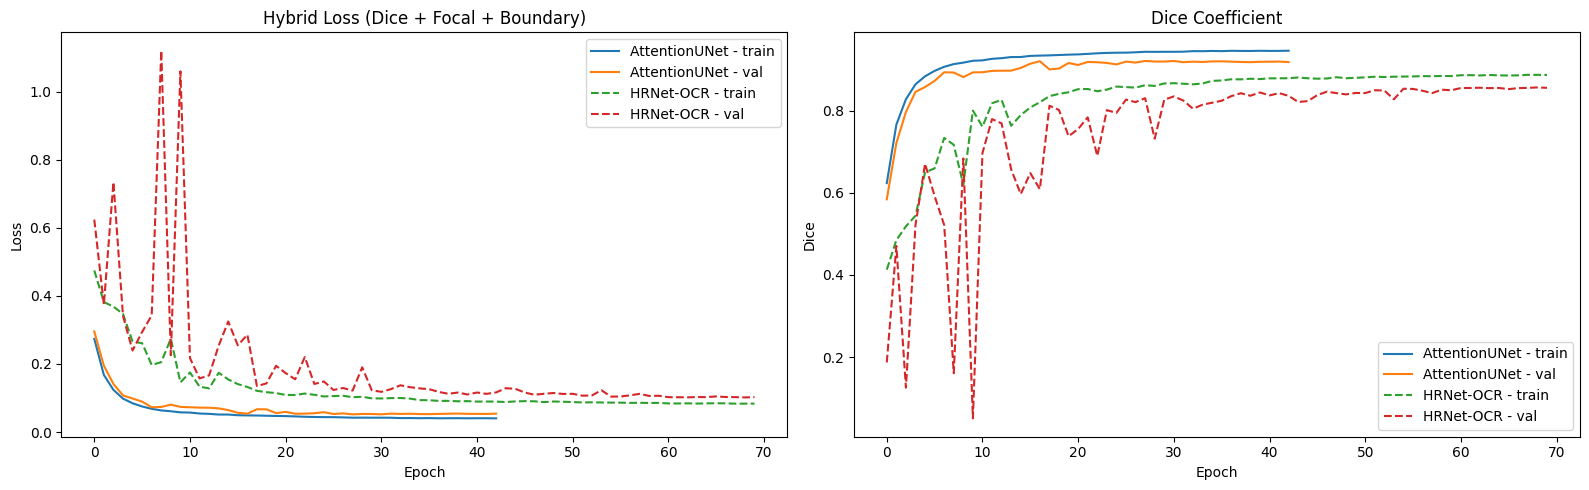

In [21]:
# ---- 8.2 Training curves, overlaid -----------------------------------------
if training_generator is not None:
    ah, hh = attn_history.history, hrnet_history.history
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(ah['loss'], label='AttentionUNet - train')
    axes[0].plot(ah['val_loss'], label='AttentionUNet - val')
    axes[0].plot(hh['loss'], '--', label='HRNet-OCR - train')
    axes[0].plot(hh['val_loss'], '--', label='HRNet-OCR - val')
    axes[0].set_title('Hybrid Loss (Dice + Focal + Boundary)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

    axes[1].plot(ah['dice_coef'], label='AttentionUNet - train')
    axes[1].plot(ah['val_dice_coef'], label='AttentionUNet - val')
    axes[1].plot(hh['dice_coef'], '--', label='HRNet-OCR - train')
    axes[1].plot(hh['val_dice_coef'], '--', label='HRNet-OCR - val')
    axes[1].set_title('Dice Coefficient')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_training_curves.png'), dpi=120)
    plt.show()
else:
    print("Skipping training-curve comparison (no data / models not trained).")


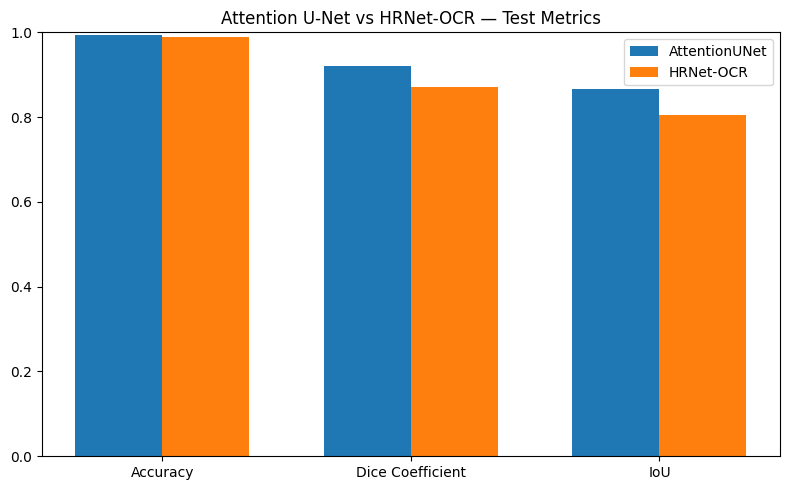

In [22]:
# ---- 8.3 Metrics bar chart --------------------------------------------------
plot_df = comparison_df[comparison_df['Metric'] != 'Loss'].dropna()
if not plot_df.empty:
    x = np.arange(len(plot_df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width / 2, plot_df['AttentionUNet'], width, label='AttentionUNet')
    ax.bar(x + width / 2, plot_df['HRNet-OCR'], width, label='HRNet-OCR')
    ax.set_xticks(x); ax.set_xticklabels(plot_df['Metric'])
    ax.set_ylim(0, 1)
    ax.set_title('Attention U-Net vs HRNet-OCR — Test Metrics')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_metrics_bar.png'), dpi=120)
    plt.show()
else:
    print("Skipping metrics bar chart (no evaluated metrics).")


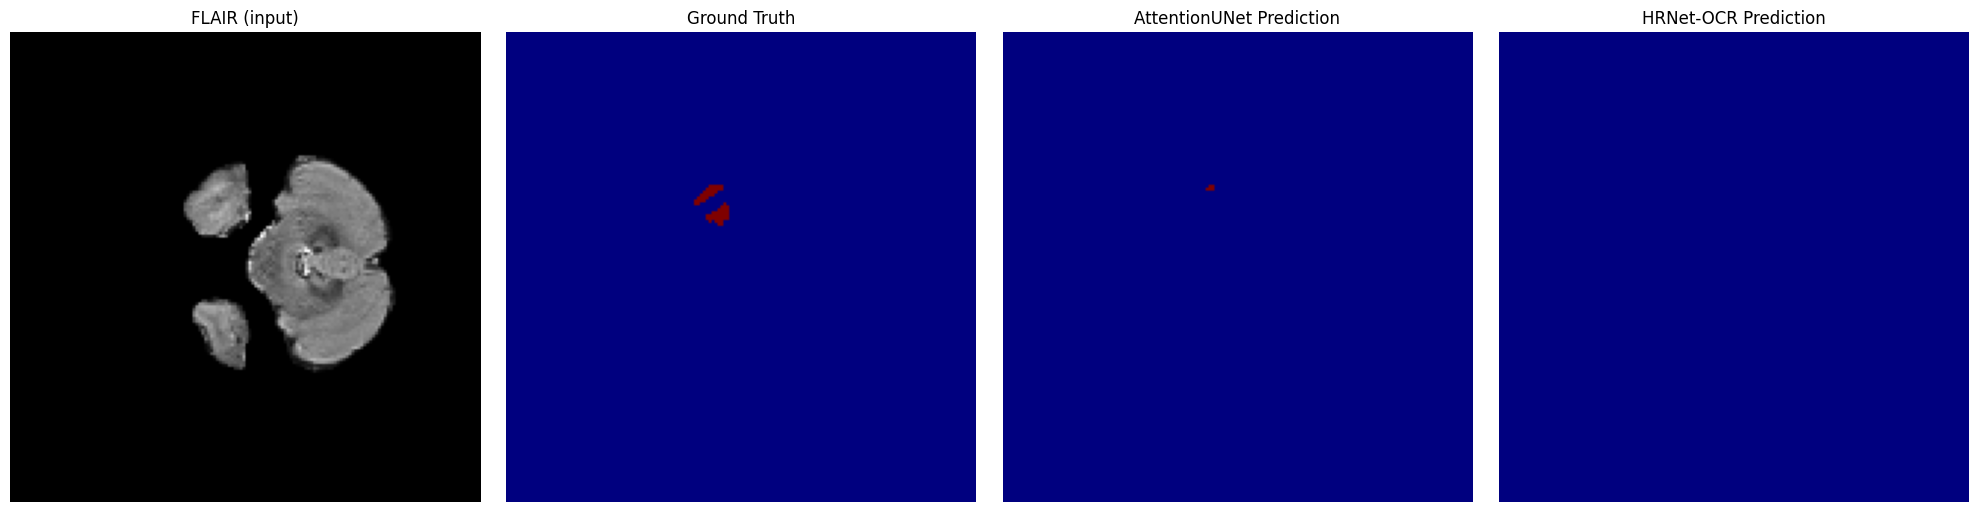

In [23]:
# ---- 8.4 Side-by-side MRI segmentation predictions --------------------------
def side_by_side_prediction(sample_index=0):
    if test_generator is None or len(test_generator) == 0:
        print("No test data available for visual comparison.")
        return
    X, Y = test_generator[0]
    idx = min(sample_index, X.shape[0] - 1)
    img, gt = X[idx], Y[idx]

    attn_pred = attn_trainer.predict(img[None, ...])[0]
    hrnet_pred = hrnet_trainer.predict(img[None, ...])[0]

    gt_c = np.argmax(gt, axis=-1)
    attn_c = np.argmax(attn_pred, axis=-1)
    hrnet_c = np.argmax(hrnet_pred, axis=-1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img[:, :, 0], cmap='gray'); axes[0].set_title('FLAIR (input)'); axes[0].axis('off')
    axes[1].imshow(gt_c, cmap='jet', vmin=0, vmax=NUM_CLASSES - 1); axes[1].set_title('Ground Truth'); axes[1].axis('off')
    axes[2].imshow(attn_c, cmap='jet', vmin=0, vmax=NUM_CLASSES - 1); axes[2].set_title('AttentionUNet Prediction'); axes[2].axis('off')
    axes[3].imshow(hrnet_c, cmap='jet', vmin=0, vmax=NUM_CLASSES - 1); axes[3].set_title('HRNet-OCR Prediction'); axes[3].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_prediction_sample{sample_index}.png'), dpi=120)
    plt.show()

if training_generator is not None:
    side_by_side_prediction(sample_index=0)
else:
    print("Skipping visual comparison (no data / models not trained).")


In [24]:
# ---- 8.5 Auto-generated strengths / weaknesses summary ----------------------
def summarize_comparison(attn_results, hrnet_results):
    lines = []
    a_dice, h_dice = attn_results.get('dice_coef'), hrnet_results.get('dice_coef')
    a_iou, h_iou = attn_results.get('iou_score'), hrnet_results.get('iou_score')
    a_acc, h_acc = attn_results.get('accuracy'), hrnet_results.get('accuracy')

    if None in (a_dice, h_dice, a_iou, h_iou, a_acc, h_acc):
        return "Train both models first to generate a strengths / weaknesses summary."

    lines.append("**Attention U-Net**")
    lines.append(f"- Dice: {a_dice:.4f} | IoU: {a_iou:.4f} | Accuracy: {a_acc:.4f}")
    lines.append("- Strength: attention gates sharpen tumor **boundaries**, so it tends to"
                  " do well on irregular / small enhancing-tumor regions.")
    lines.append("- Weakness: purely encoder–decoder — can miss broader contextual cues"
                  " that span the whole slice.")
    lines.append("")
    lines.append("**HRNet-OCR**")
    lines.append(f"- Dice: {h_dice:.4f} | IoU: {h_iou:.4f} | Accuracy: {h_acc:.4f}")
    lines.append("- Strength: keeps a full-resolution stream alongside multi-scale context,"
                  " so it tends to do well on **overall tumor structure / large regions**.")
    lines.append("- Weakness: OCR's region-representation step can blur fine edges relative"
                  " to an explicit attention-gated decoder.")
    lines.append("")
    better_dice = "Attention U-Net" if a_dice >= h_dice else "HRNet-OCR"
    lines.append(f"**Overall (by Dice):** {better_dice} scored higher on this test split.")
    return "\n".join(lines)

summary_md = summarize_comparison(attn_results, hrnet_results)
print(summary_md)


**Attention U-Net**
- Dice: 0.9200 | IoU: 0.8652 | Accuracy: 0.9929
- Strength: attention gates sharpen tumor **boundaries**, so it tends to do well on irregular / small enhancing-tumor regions.
- Weakness: purely encoder–decoder — can miss broader contextual cues that span the whole slice.

**HRNet-OCR**
- Dice: 0.8711 | IoU: 0.8053 | Accuracy: 0.9898
- Strength: keeps a full-resolution stream alongside multi-scale context, so it tends to do well on **overall tumor structure / large regions**.
- Weakness: OCR's region-representation step can blur fine edges relative to an explicit attention-gated decoder.

**Overall (by Dice):** Attention U-Net scored higher on this test split.


## 🖼️ 8.6 Clean Segmentation Gallery (multi-sample dashboards)

Renders the exact 3-panel layout from your reference image —
**Original MRI | Predicted Segmentation Mask | Segmented Output (Overlay)**,
dark background, bold white titles, crimson tumor overlay, Background/Tumor
legend — for several different test slices, using the trained Attention
U-Net. Slices with a tiny/no tumor are skipped so every dashboard looks
clean like the example, not a handful of stray pixels.


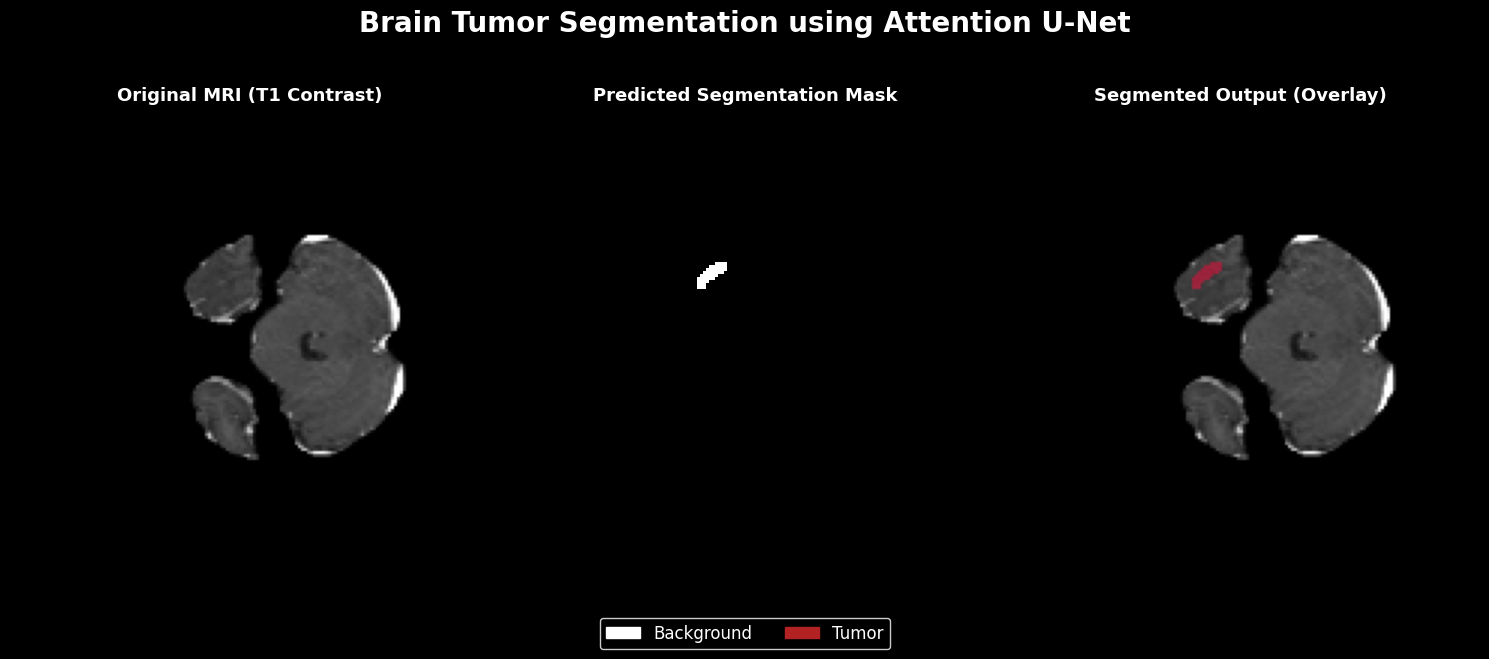

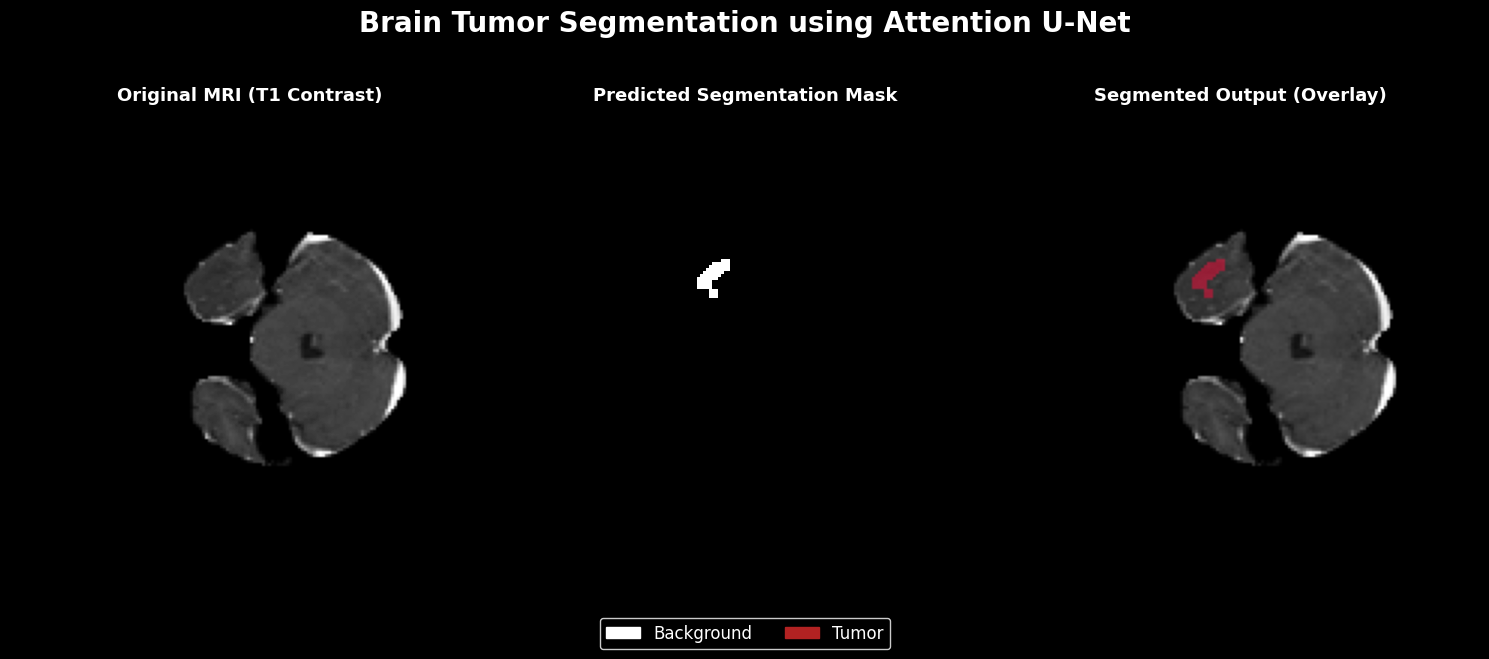

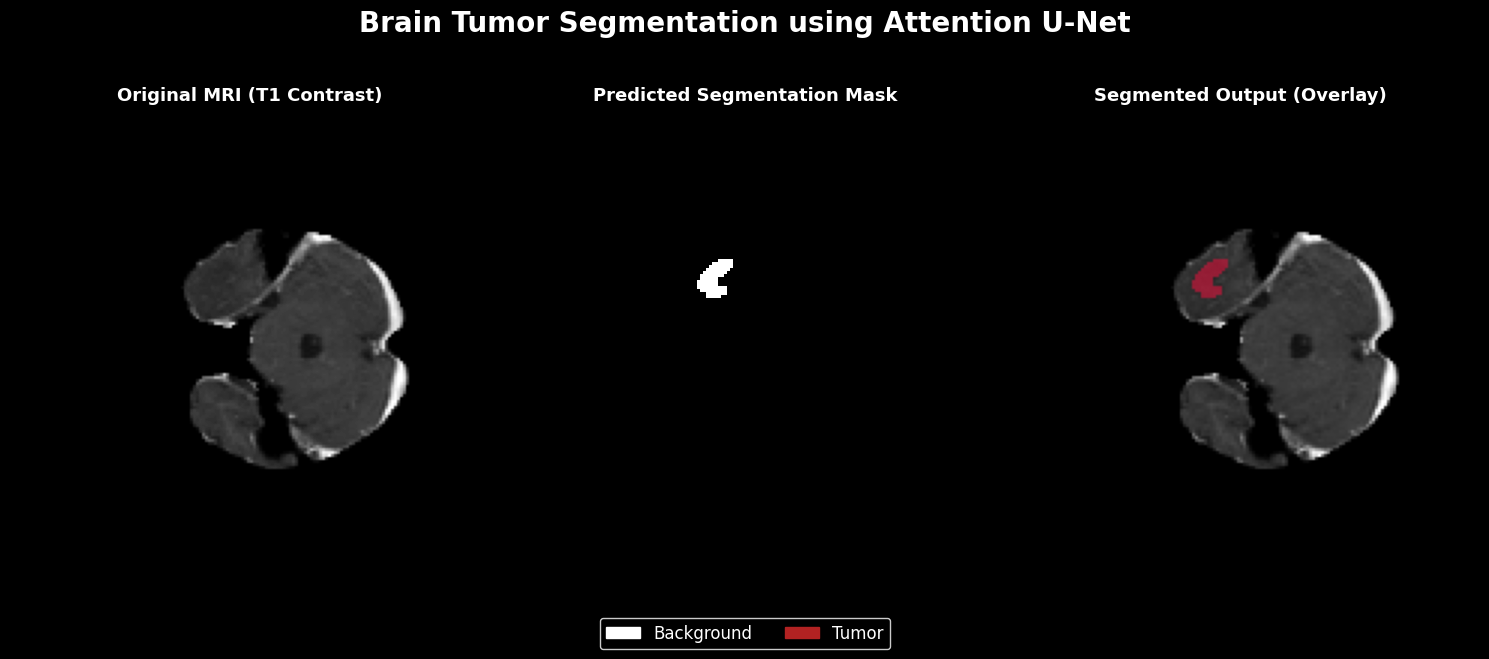

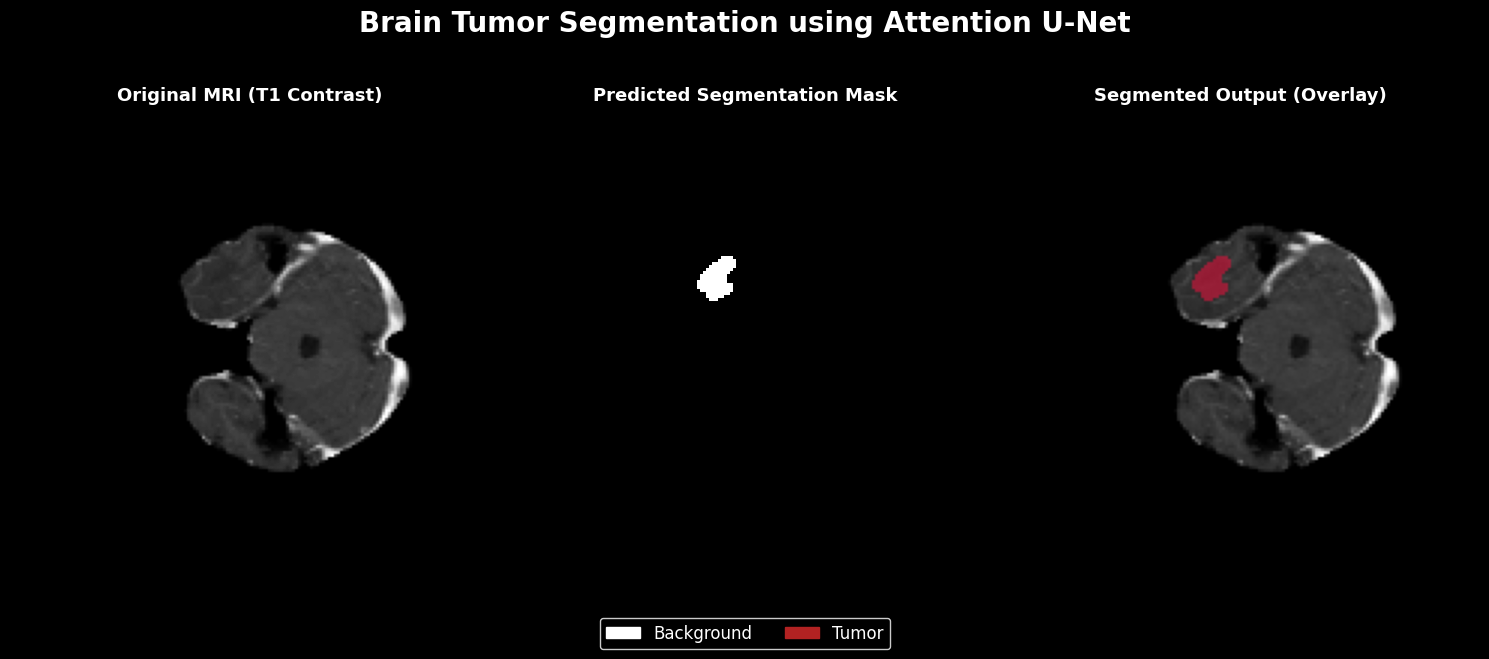

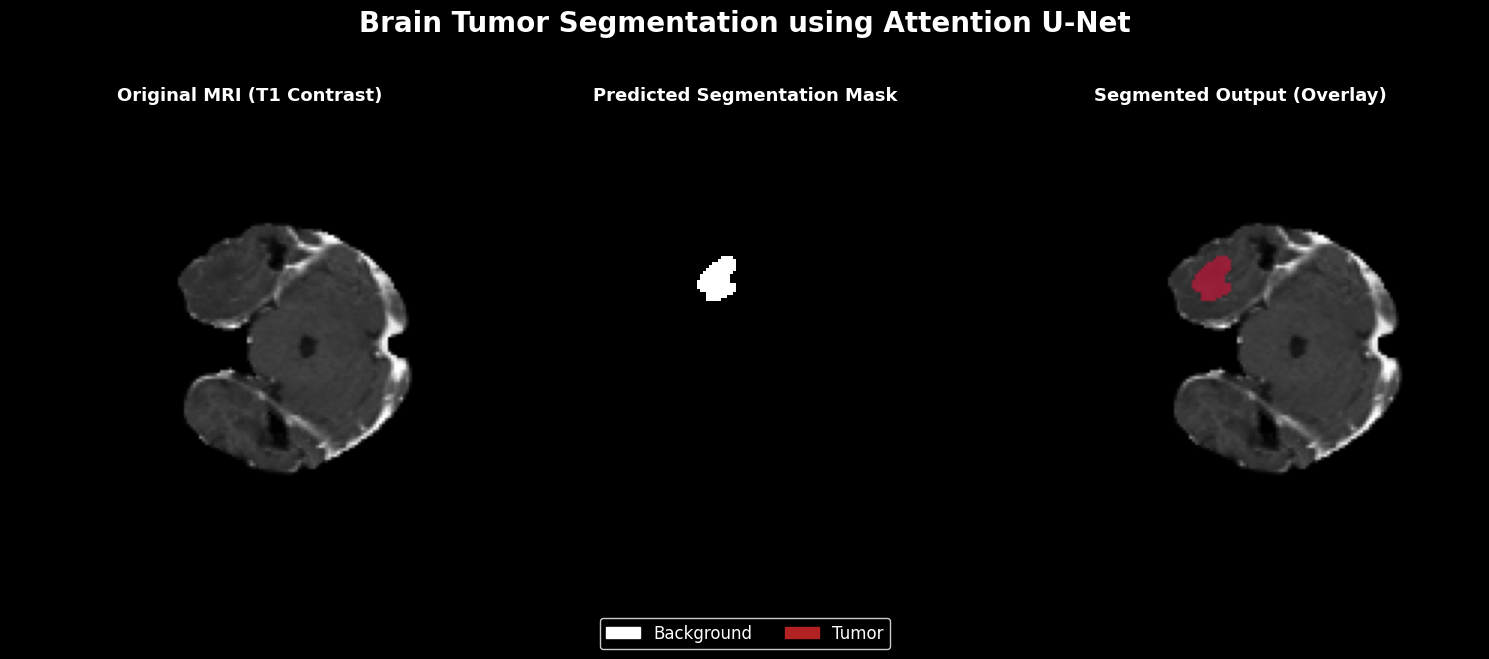

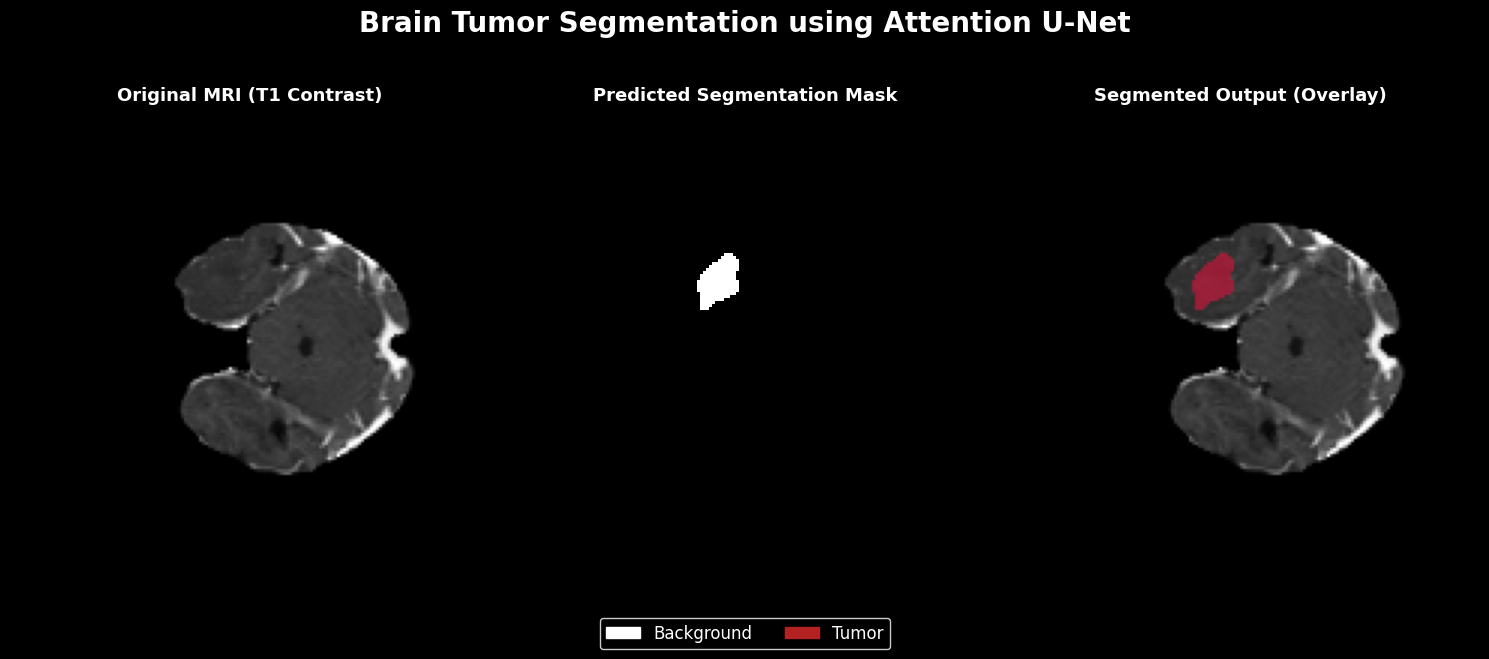

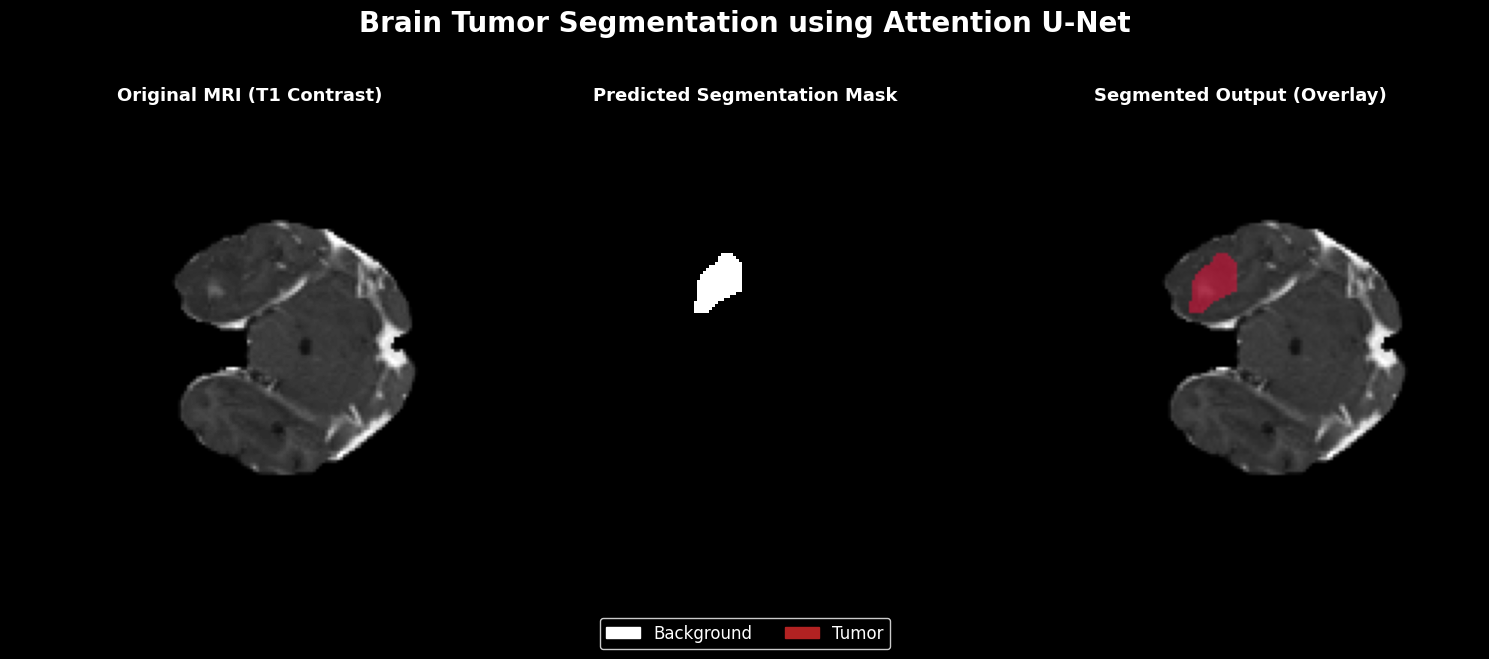

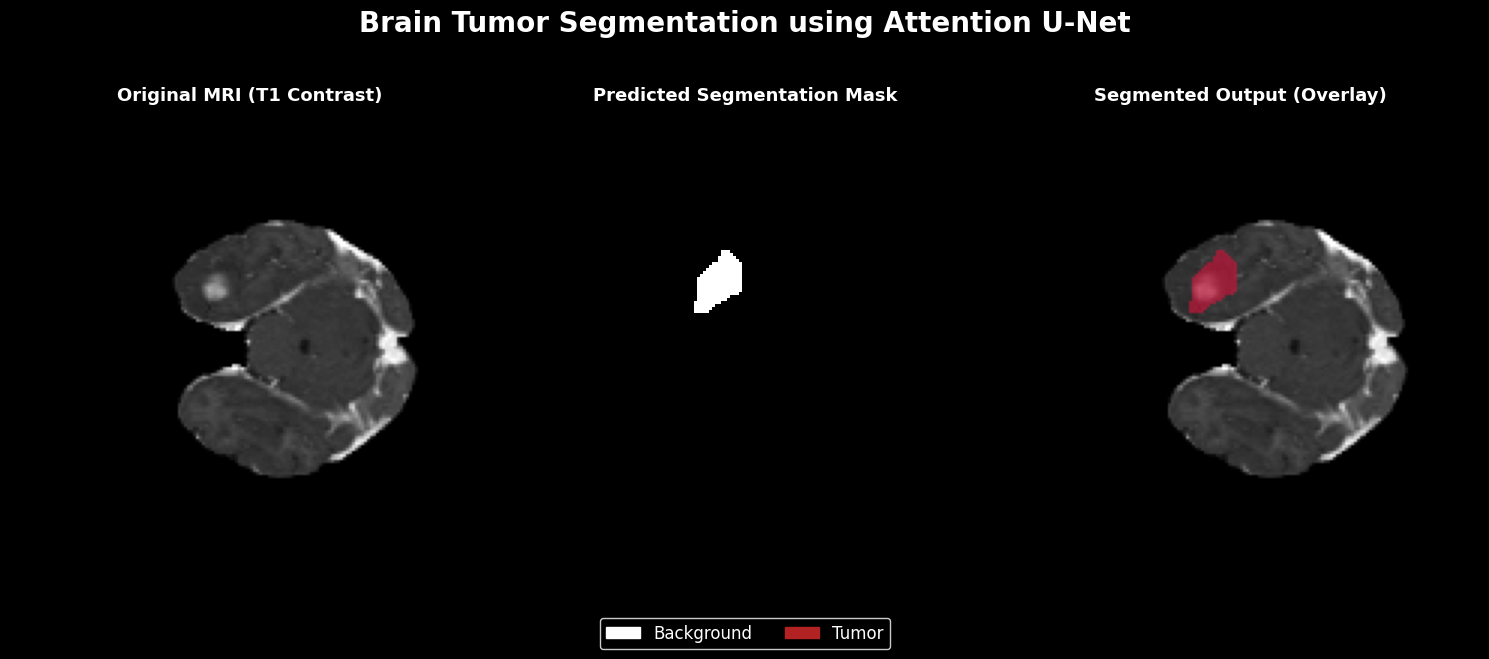

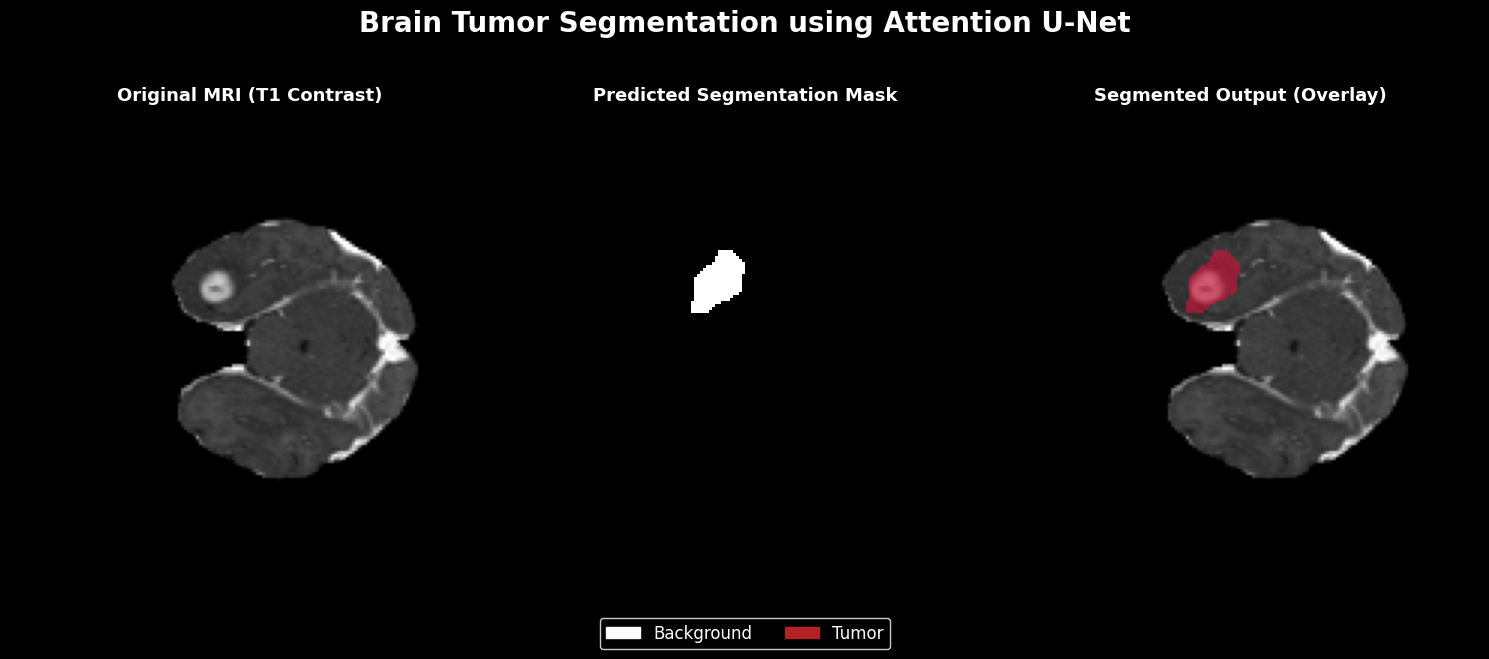

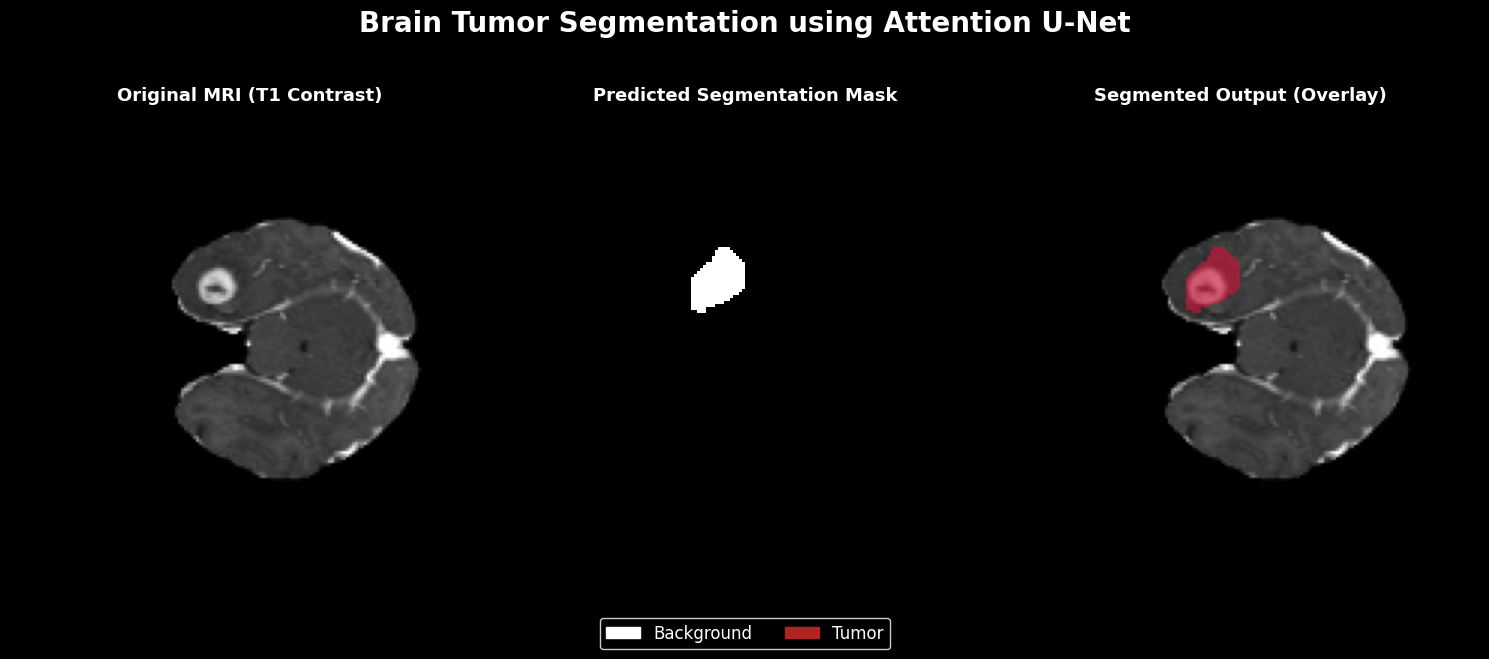

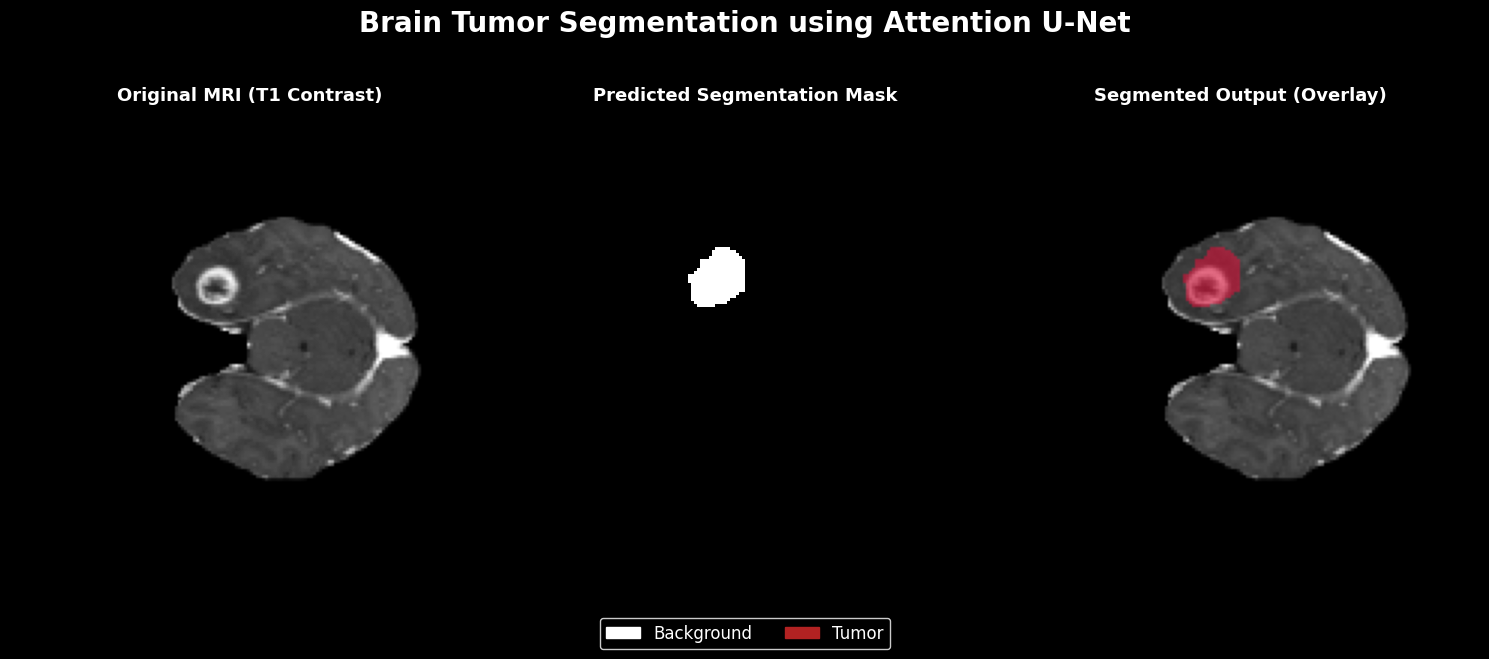

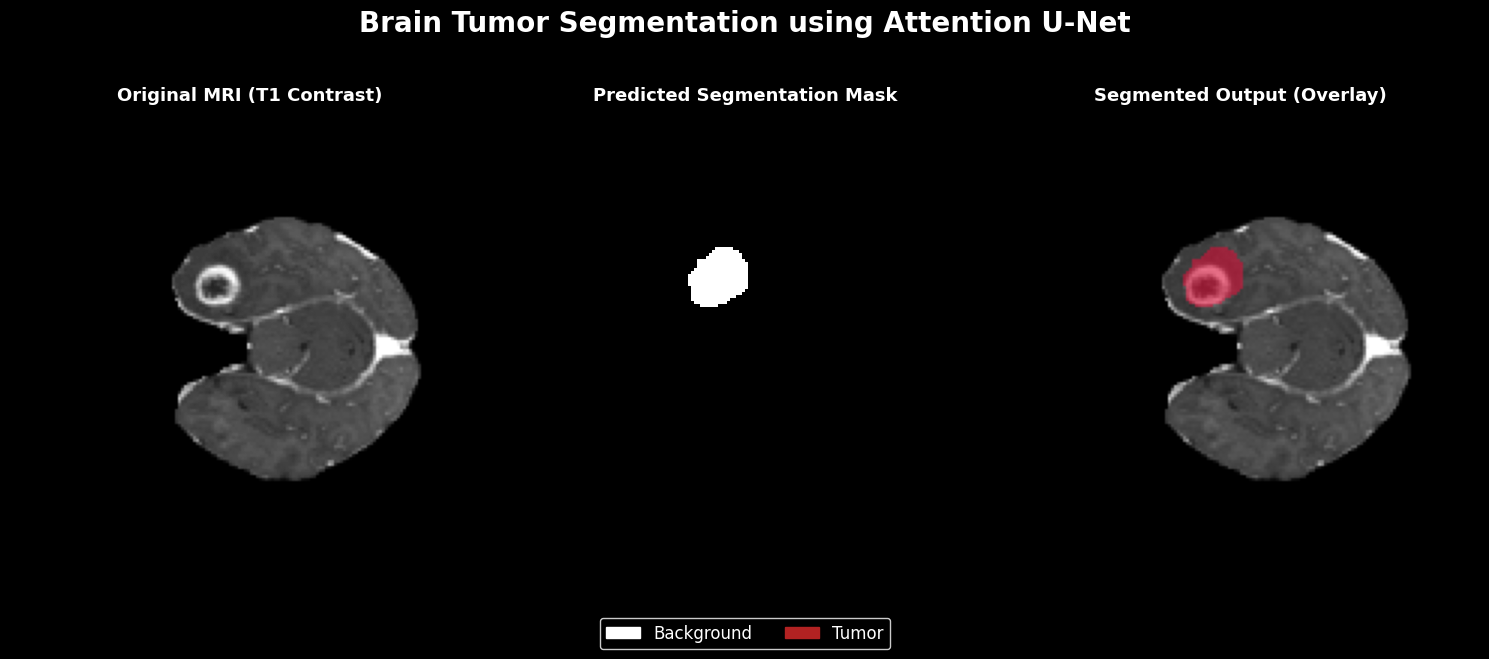

In [25]:
# ---- 8.6 Multi-sample segmentation gallery (matches the reference image) ----
import matplotlib.patches as mpatches

def plot_segmentation_dashboard(trainer, img, model_name="Attention U-Net",
                                 modality_idx=2, save_path=None, clean_mask=True):
    """One dashboard: Original MRI | Predicted Mask | Overlay — styled like
    the reference image (dark background, bold white titles, crimson tumor
    overlay, Background/Tumor legend)."""
    pred = trainer.predict(img[None, ...])[0]
    pred_mask = (pred[..., 1] > 0.5).astype(np.uint8)   # tumor channel, thresholded

    if clean_mask:
        kernel = np.ones((3, 3), np.uint8)
        pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_OPEN, kernel)
        pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

    base = img[:, :, modality_idx]   # T1CE by default (MODALITY_NAMES index 2)
    # Match matplotlib's automatic gray-cmap contrast stretch so panel 1 and
    # panel 3's brain brightness look identical (imshow on a raw RGB array
    # does NOT auto-scale the way cmap='gray' does).
    b_min, b_max = base.min(), base.max()
    base_norm = (base - b_min) / (b_max - b_min + 1e-8)

    fig = plt.figure(figsize=(15, 6), facecolor='black')
    fig.suptitle(f"Brain Tumor Segmentation using {model_name}",
                 color='white', fontsize=20, fontweight='bold', y=1.03)

    ax1 = fig.add_subplot(1, 3, 1, facecolor='black')
    ax1.imshow(base, cmap='gray')
    ax1.set_title("Original MRI (T1 Contrast)", color='white', fontsize=13, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(1, 3, 2, facecolor='black')
    ax2.imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
    ax2.set_title("Predicted Segmentation Mask", color='white', fontsize=13, fontweight='bold')
    ax2.axis('off')

    ax3 = fig.add_subplot(1, 3, 3, facecolor='black')
    base_rgb = np.stack([base_norm, base_norm, base_norm], axis=-1)
    tumor_color = np.array([220, 20, 60]) / 255.0   # crimson, solid & saturated
    alpha = 0.6
    overlay_rgb = base_rgb.copy()
    m = pred_mask.astype(bool)
    overlay_rgb[m] = (1 - alpha) * base_rgb[m] + alpha * tumor_color
    ax3.imshow(overlay_rgb)
    ax3.set_title("Segmented Output (Overlay)", color='white', fontsize=13, fontweight='bold')
    ax3.axis('off')

    bg_patch = mpatches.Patch(facecolor='white', edgecolor='white', label='Background')
    tumor_patch = mpatches.Patch(facecolor='firebrick', edgecolor='firebrick', label='Tumor')
    fig.legend(handles=[bg_patch, tumor_patch], loc='lower center', ncol=2,
               facecolor='black', edgecolor='white', labelcolor='white',
               bbox_to_anchor=(0.5, -0.05), fontsize=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, facecolor='black', bbox_inches='tight')
    plt.show()


def show_segmentation_gallery(trainer, generator, model_name="Attention U-Net",
                               n_samples=6, min_tumor_area=200):
    """Scans batches of `generator` and renders a dashboard for the first
    `n_samples` slices with a decently sized tumor, so the gallery looks
    clean instead of showing tiny specks."""
    if generator is None:
        print("No test data available for the gallery.")
        return

    shown = 0
    for b in range(len(generator)):
        X, Y = generator[b]
        for i in range(X.shape[0]):
            tumor_area = Y[i][..., 1].sum()
            if tumor_area < min_tumor_area:
                continue
            save_path = os.path.join(OUTPUT_DIR, f"gallery_{model_name}_{shown}.png")
            plot_segmentation_dashboard(trainer, X[i], model_name=model_name,
                                         save_path=save_path)
            shown += 1
            if shown >= n_samples:
                return
    if shown == 0:
        print("No slices met min_tumor_area — lower the threshold and retry.")

if training_generator is not None:
    show_segmentation_gallery(attn_trainer, test_generator,
                               model_name="Attention U-Net", n_samples=12,
                               min_tumor_area=150)
else:
    print("Skipping gallery (no data / model not trained).")


### 🖼️ 8.7 Same gallery for HRNet-OCR

Same dashboards, same test slices where possible, using the trained
HRNet-OCR model — so you can visually compare both models on the same
cases, not just the metrics table.


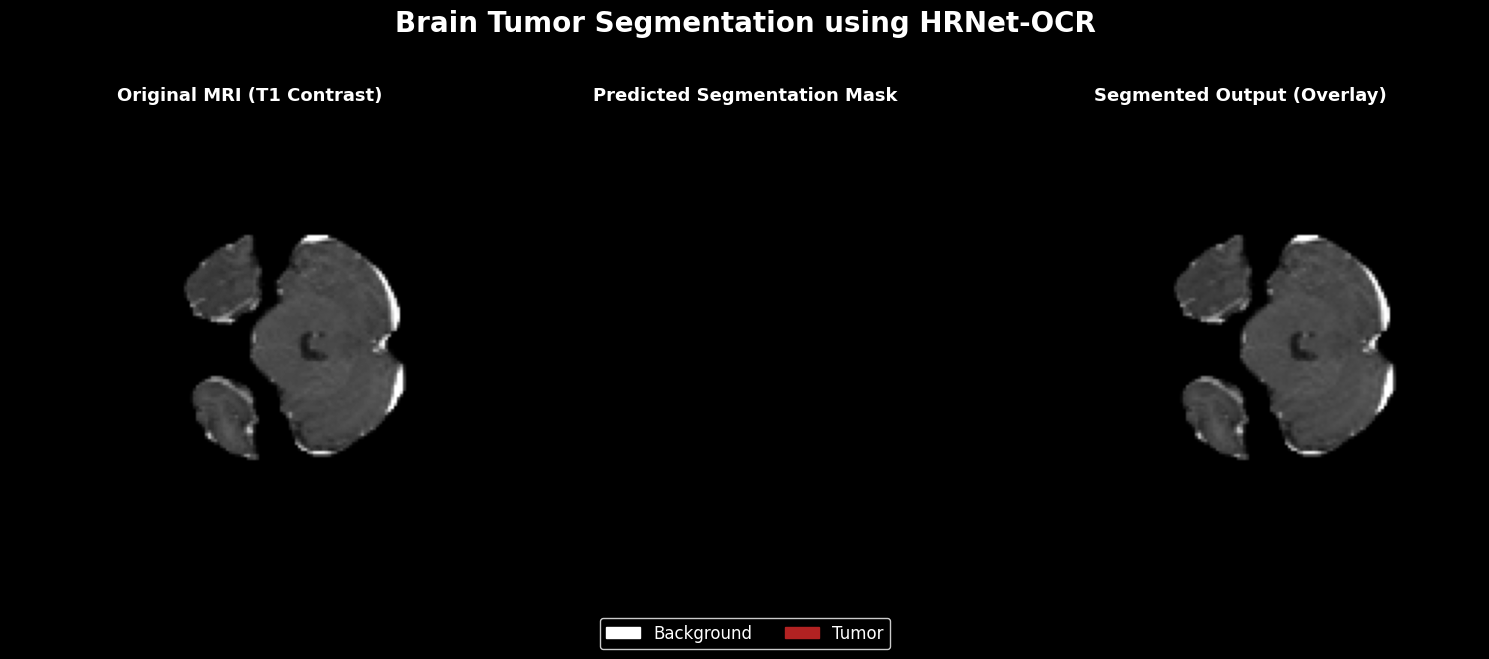

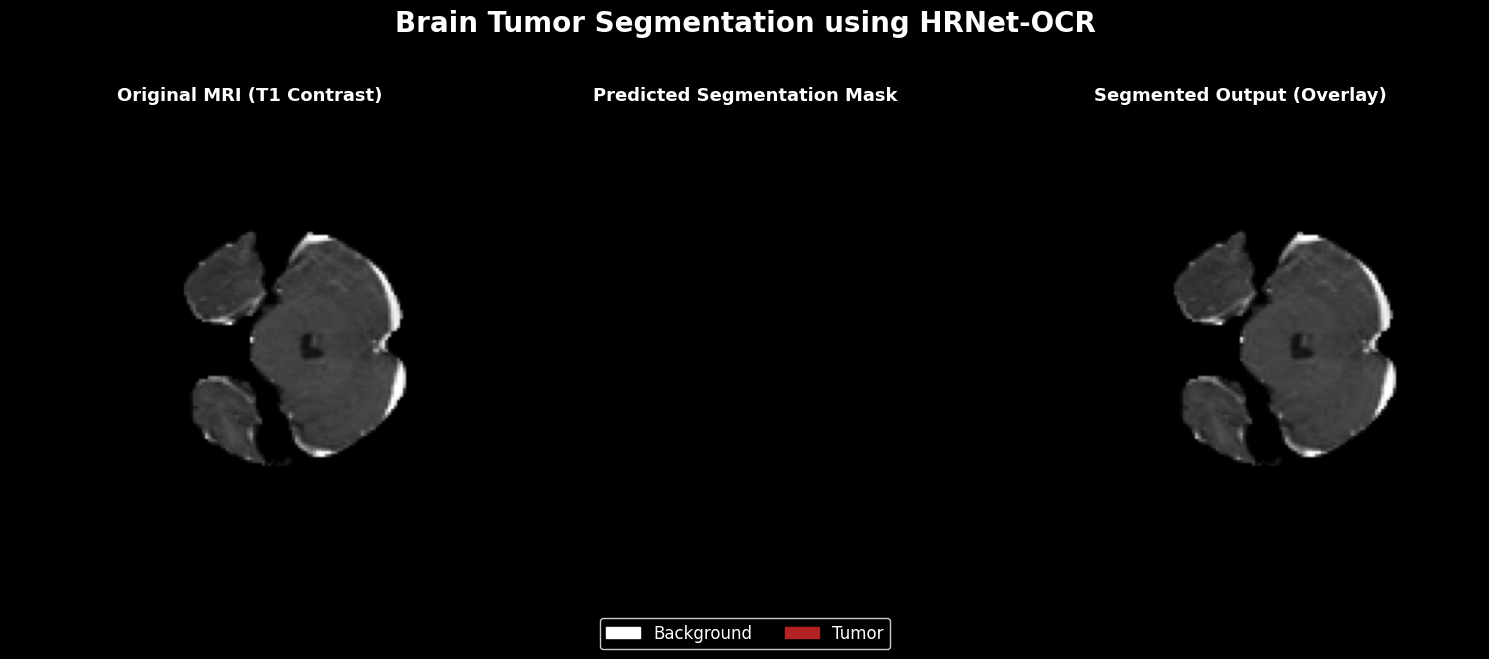

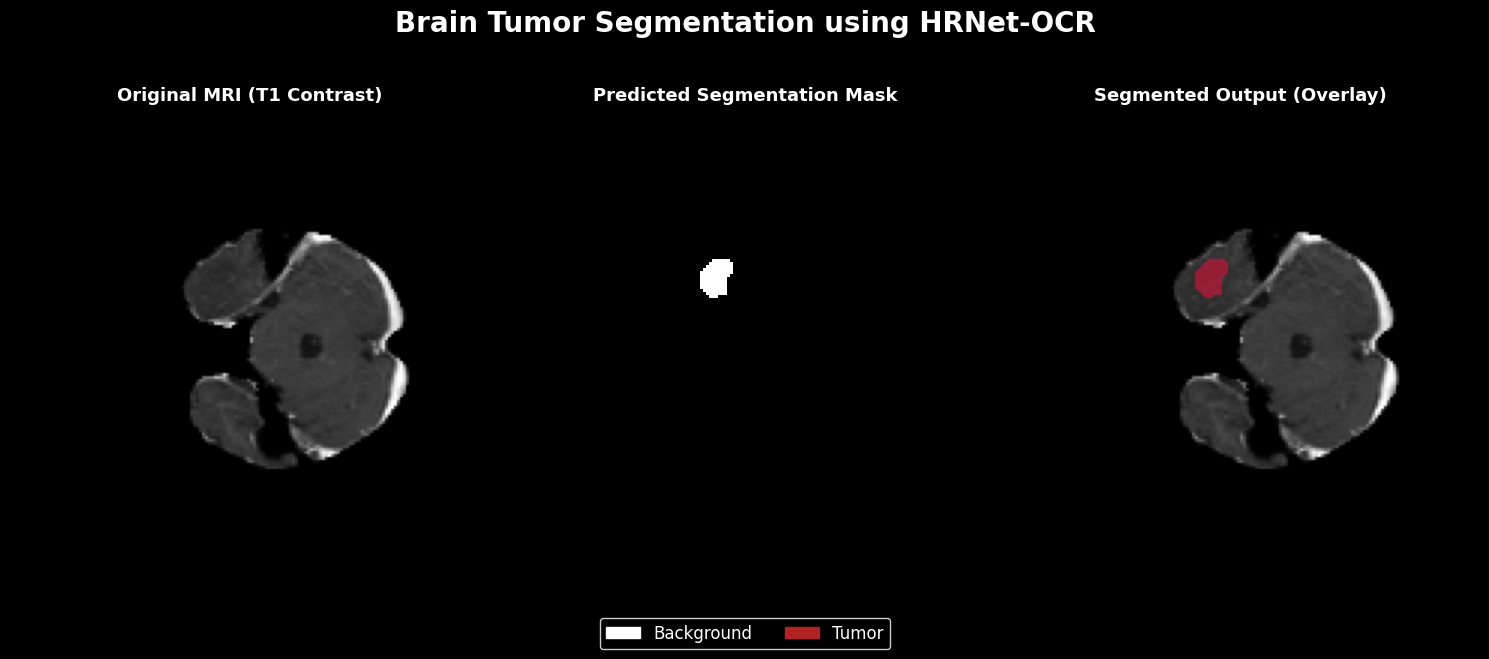

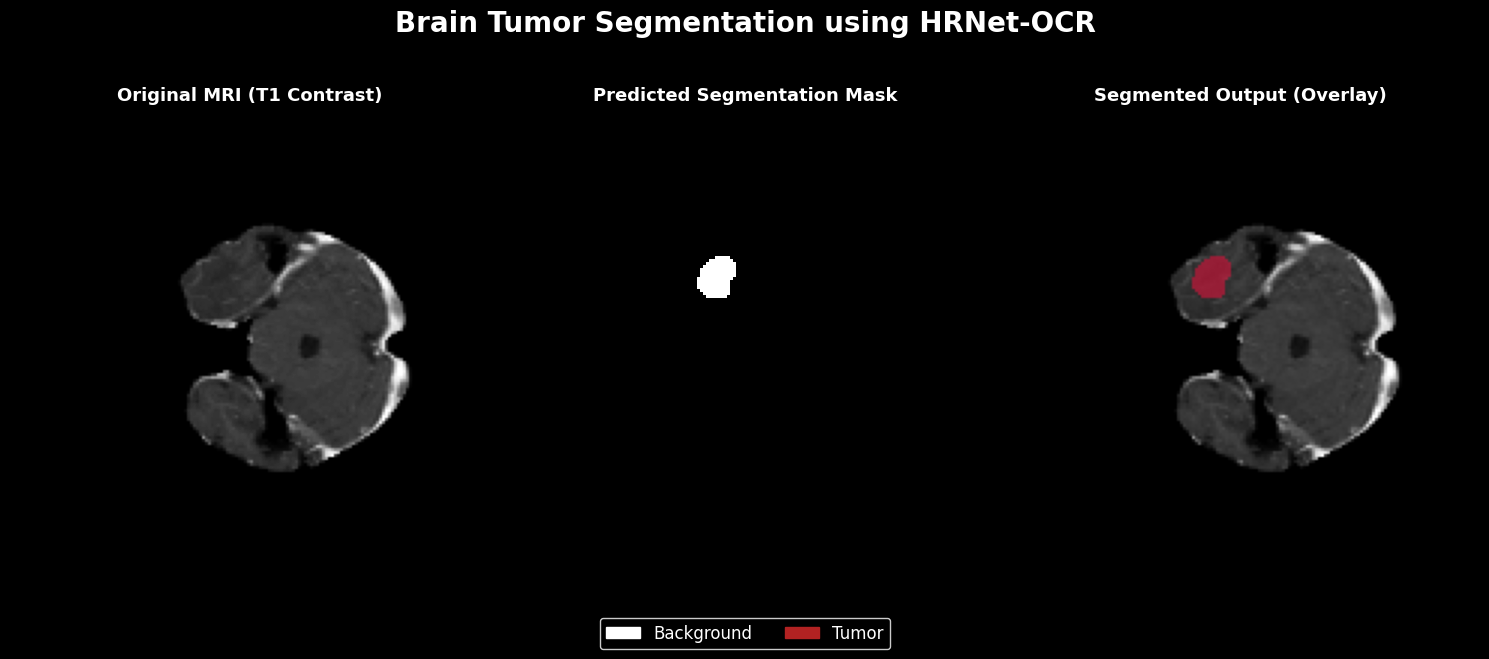

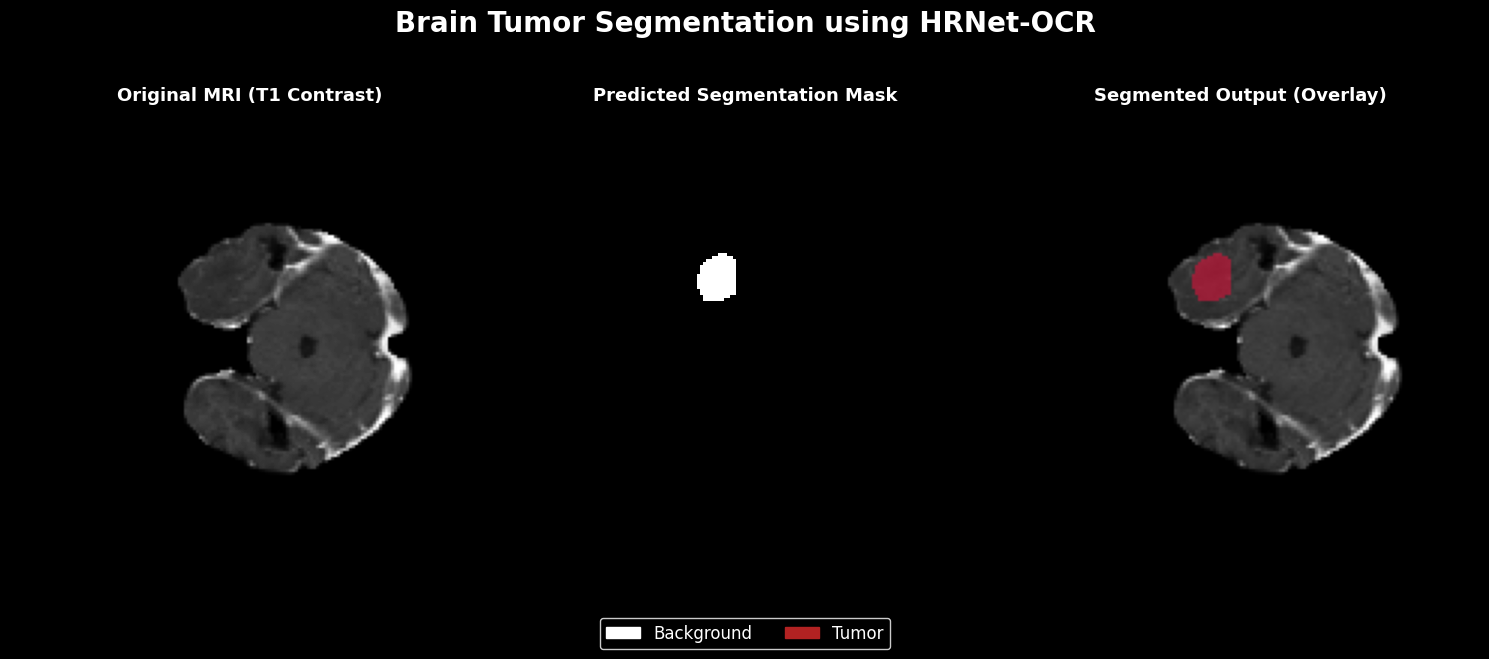

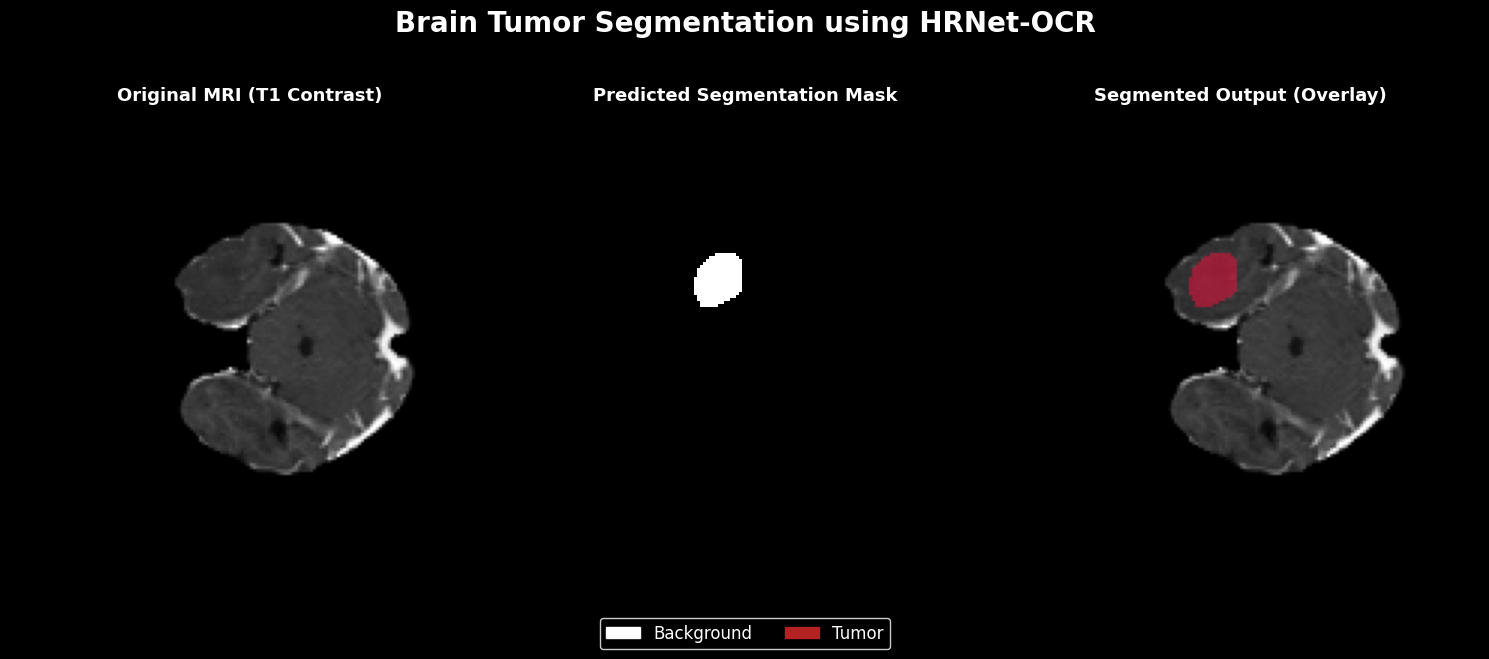

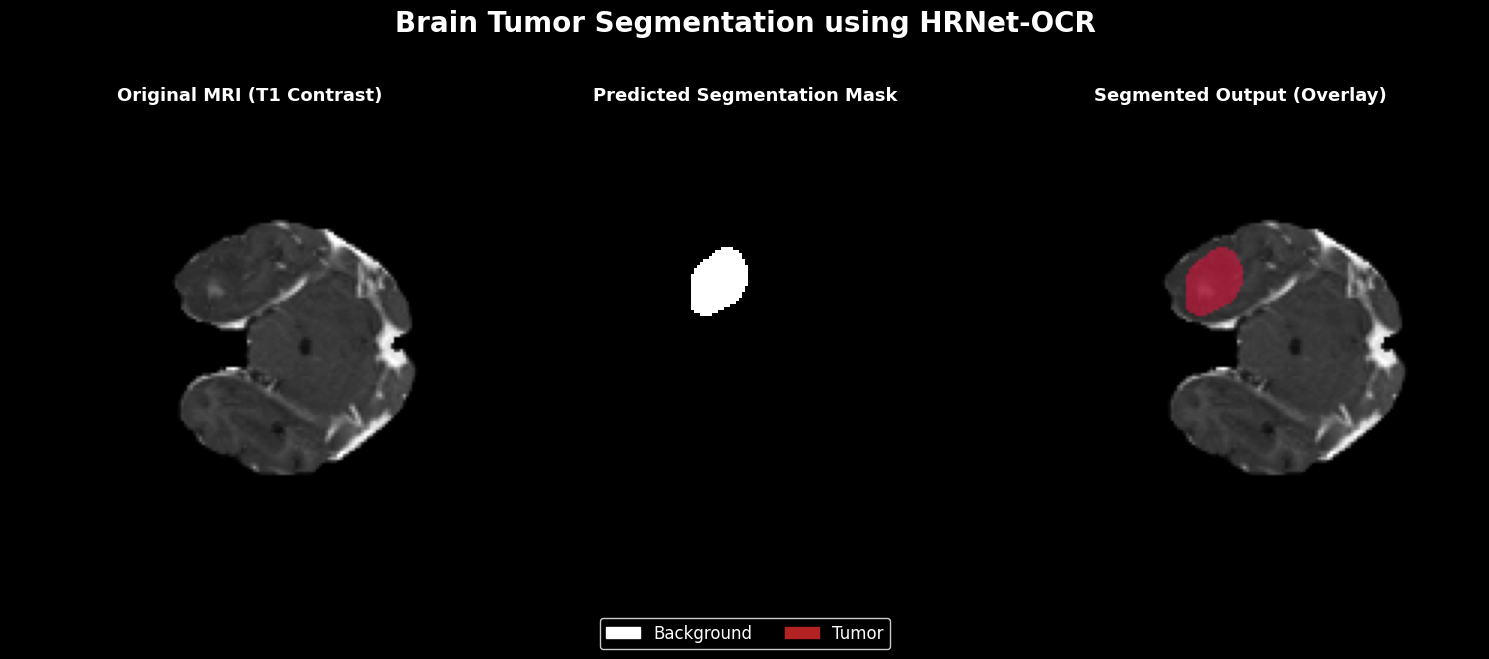

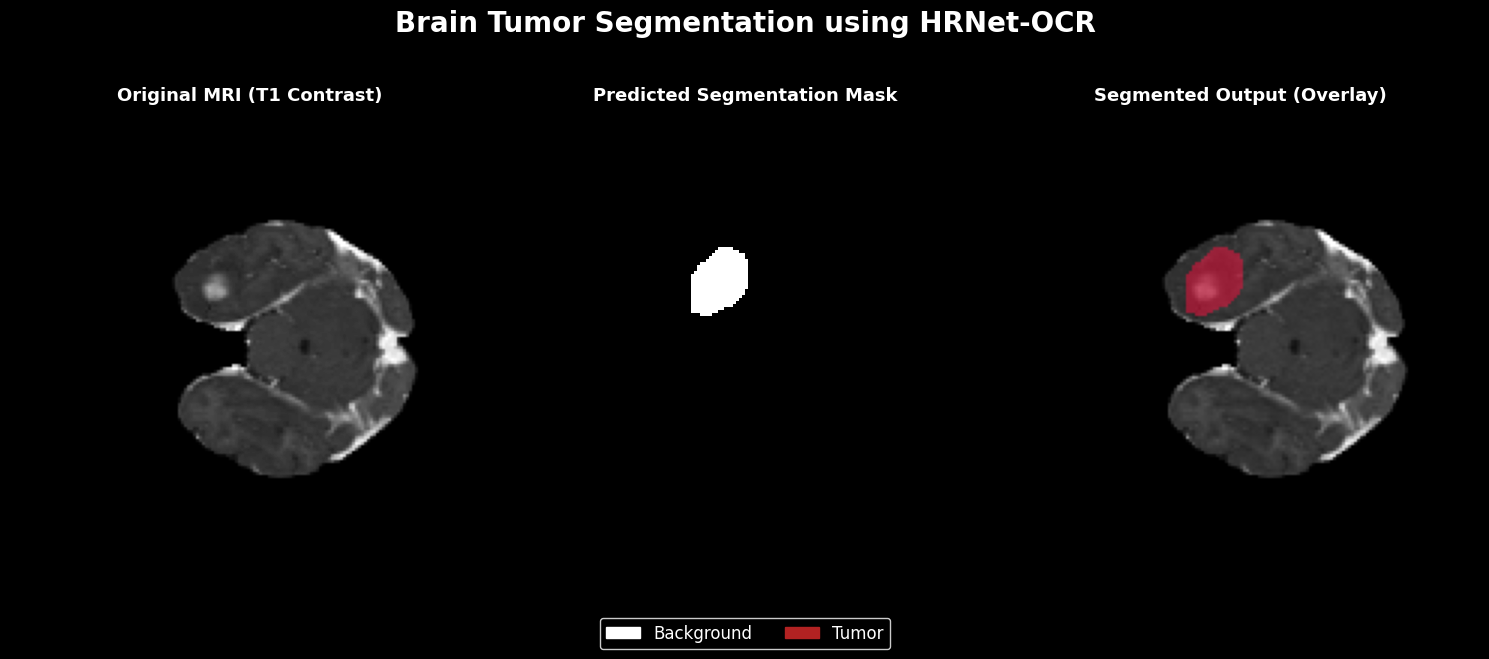

In [26]:
if training_generator is not None:
    show_segmentation_gallery(hrnet_trainer, test_generator,
                               model_name="HRNet-OCR", n_samples=8,
                               min_tumor_area=150)
else:
    print("Skipping HRNet-OCR gallery (no data / model not trained).")


## 💾 9. Save Both Trained Models

In [27]:
if training_generator is not None:
    attn_final_path = attn_trainer.save()
    hrnet_final_path = hrnet_trainer.save()
    print(f"Attention U-Net saved to: {attn_final_path}")
    print(f"HRNet-OCR saved to:       {hrnet_final_path}")
else:
    print("Nothing to save — no data / models were not trained.")


Attention U-Net saved to: outputs/AttentionUNet/AttentionUNet_final.keras
HRNet-OCR saved to:       outputs/HRNetOCR/HRNetOCR_final.keras
